## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, timedelta

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [3]:
from funcoes_monitoramento import *
from funcoes_psi import *

## Diretório

In [4]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base Blend4 em Produção

In [5]:
df_raw = pd.read_csv(ANALYTICS_DIR/"df_predict_blend3.csv")

df_raw["flag_tem__contratos_anteriores"] = df_raw["flag_tem__contratos_anteriores"].replace({"True": 1, "False": 0, "0": 0, "1": 1})
df_raw["flag_teve_boleto_atrasado__contratos_anteriores"] = df_raw["flag_teve_boleto_atrasado__contratos_anteriores"].replace({"True": 1, "False": 0, "0": 0, "1": 1})

In [6]:
df_uniprop = df_raw[df_raw["qtd_proponentes"] == 1].copy()

df_multprop = df_raw[df_raw["qtd_proponentes"] >= 2].copy()

In [7]:
df = df_uniprop[(df_uniprop["REGRA_BLEND_3"] == "BLEND3")
&(df_uniprop["income"] > 0) #Essa regra deverá ser excluída quando o modelo for implementado
].copy()

In [8]:
df_bvs = df_uniprop[(df_uniprop["REGRA_BLEND_3"] == "E_BVS")
].copy()

In [9]:
df_uniprop = prepare_week_columns(df_uniprop, "requested_at")
df_multprop = prepare_week_columns(df_multprop, "requested_at")
df = prepare_week_columns(df, "requested_at")
df_bvs = prepare_week_columns(df_bvs, "requested_at")

In [10]:

# df = df_raw[df_raw["message_decisao"].isin(["BLEND_4", "BLEND3_3"])]
# df_bvs = df_raw[df_raw["message_decisao"].isin(["BLEND_4", "BLEND3_3"])]

## Gráficos

In [11]:
MODEL_ORDER = [
    # "BLEND_4",
    "BLEND3_3",
    "BLEND_REGRESSAO_2026",
    "BVS_CUSTOM",
    "HVA3",
    "HVA4",
]

MODEL_ORDER_GRAPH = [
    # "BLEND_4",
    "BLEND3_3",
]

MODEL_COLOR_MAP = {
    "BLEND_4": "#3B82F6",             # blue
    "BLEND3_3": "#94A3B8",           # slate
    "BLEND_REGRESSAO_2026": "#8B5CF6",  # violet
    "BVS_CUSTOM": "#06B6D4",        # cyan
    "HVA3": "#14B8A6",               # teal
    "HVA4": "#6366F1",               # indigo
}

RATING_ORDER = ["A", "B", "C", "D", "E"]

RATING_COLOR_MAP = {
    "A": "#7DD3FC",
    "B": "#5EEAD4",
    "C": "#93C5FD",
    "D": "#818CF8",
    "E": "#334155",
}
RATING_TEXT_COLOR_MAP = {
    "A": "white",
    "B": "white",
    "C": "black",
    "D": "white",
    "E": "white",
}

In [12]:
PRE_ANALISE_ORDER = ["APROVAR", "DERIVAR", "REPROVAR"]

PRE_ANALISE_COLOR_MAP = {
    "APROVAR": "#9ECACA",
    "DERIVAR": "#B5BFE8",
    "REPROVAR": "#9AA5B1",
}

PRE_ANALISE_TEXT_COLOR_MAP = {
    "APROVAR": "white",
    "DERIVAR": "white",
    "REPROVAR": "white",
}

In [13]:
BINARY_METRICS = [
    "lead_elegivel_pre_analysis",
    "sent",
    "activated",
]

BINARY_ORDER = [0, 1]

BINARY_COLOR_MAP = {
    0: "#CBD5E1",  # muted gray
    1: "#86B8B8",  # muted teal (same family as APROVAR)
}

BINARY_TEXT_COLOR_MAP = {
    0: "white",
    1: "white",
}

BINARY_LABELS = {
    "lead_elegivel_pre_analysis": {0: "Não elegível", 1: "Elegível"},
    "sent": {0: "Não enviado", 1: "Enviado"},
    "activated": {0: "Não ativado", 1: "Ativado"},
}

METRIC_TITLES = {
    "lead_elegivel_pre_analysis": "Elegível",
    "sent": "Enviado",
    "activated": "Ativado",
}

## Multiproponente vs. Uniproponente

In [14]:
PROPONENTE_ORDER = ["Uniproponente", "Multiproponente"]

PROPONENTE_COLOR_MAP = {
    "Uniproponente": "#94A3B8",   # slate
    "Multiproponente": "#3B82F6", # blue
}

PROPONENTE_TEXT_COLOR_MAP = {
    "Uniproponente": "white",
    "Multiproponente": "white",
}

def add_tipo_proponente(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["tipo_proponente"] = np.where(
        out["qtd_proponentes"] == 1,
        "Uniproponente",
        "Multiproponente",
    )
    return out

# Use df (BLEND4 + income > 0) ou df_raw (base completa)
df_prop = add_tipo_proponente(df_raw)

print(df_prop["tipo_proponente"].value_counts(normalize=True).mul(100).round(2))
print(df_prop["tipo_proponente"].value_counts())

tipo_proponente
Uniproponente      96.13
Multiproponente     3.87
Name: proportion, dtype: float64
tipo_proponente
Uniproponente      103997
Multiproponente      4183
Name: count, dtype: int64


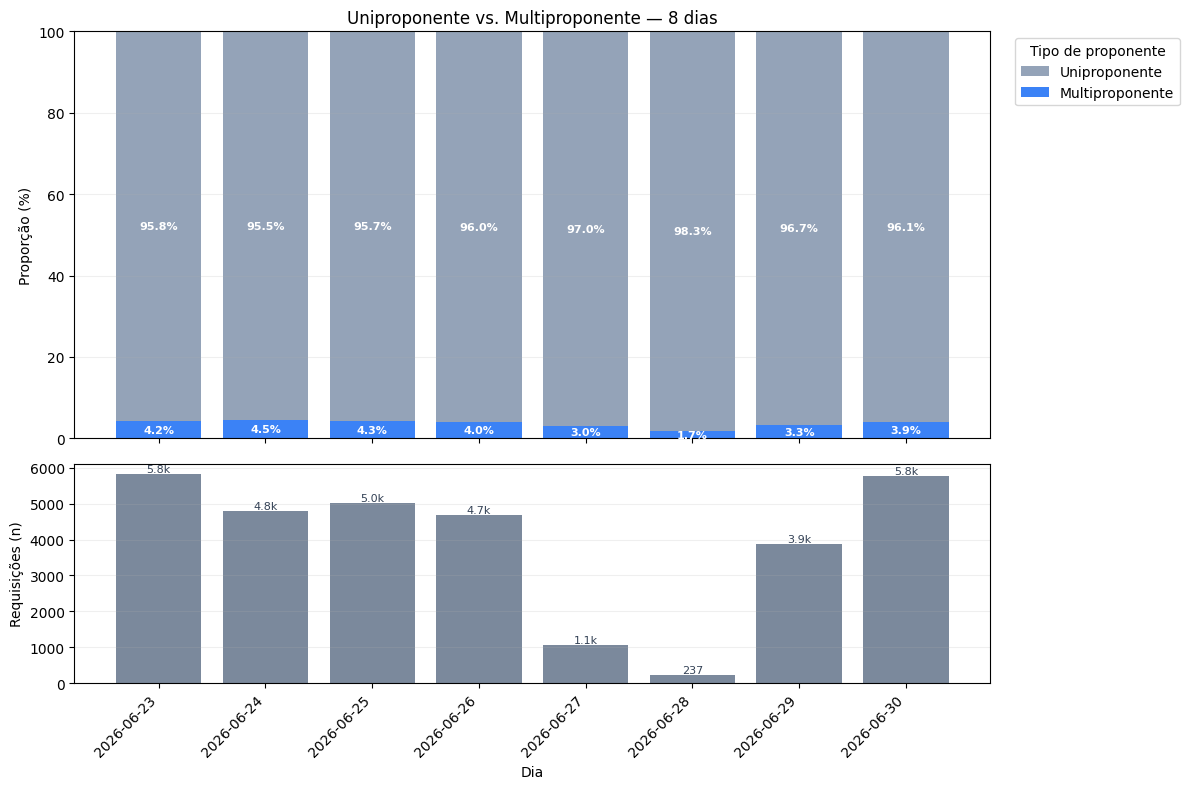

In [15]:
WINDOW_DAYS = 8

df_daily_prop = filter_monitoring_window(
    df_prop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)

plot_daily_mix(
    df_daily_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_DAYS} dias",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

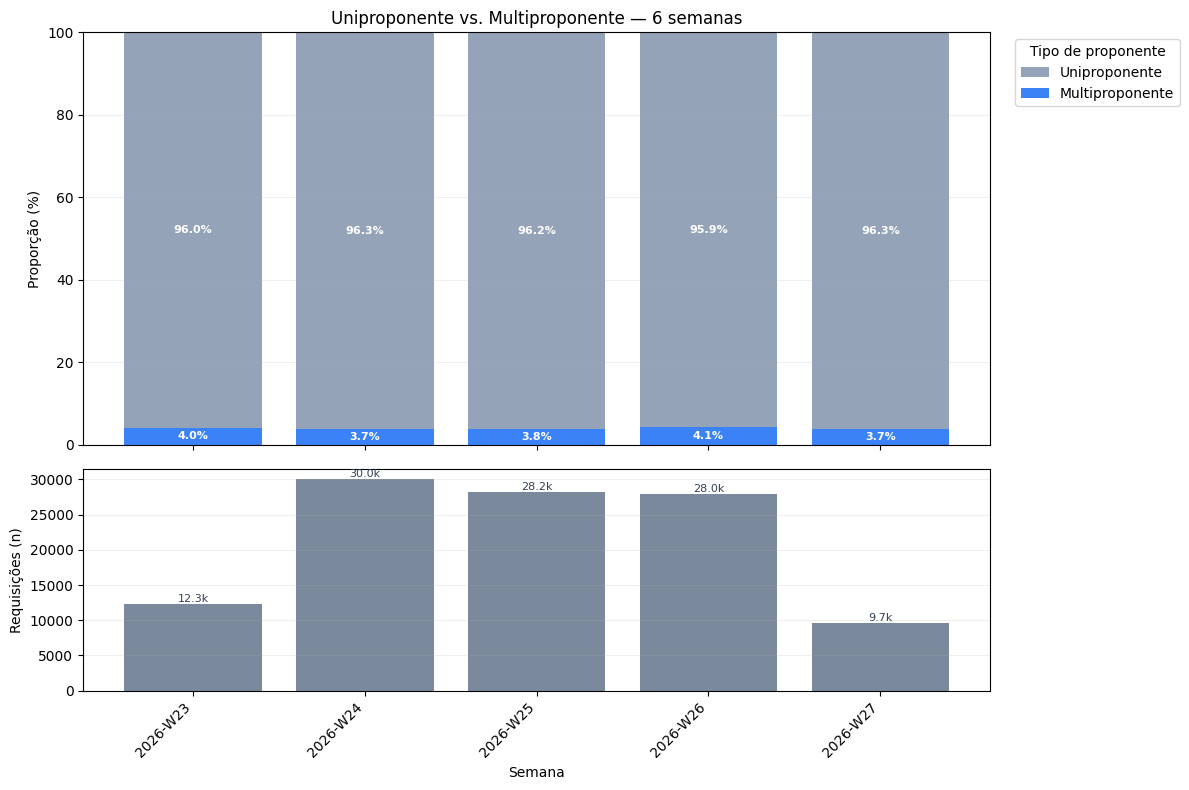

In [16]:
WINDOW_WEEKS = 6

df_weekly_prop = filter_monitoring_week_window(
    df_prop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)

plot_weekly_mix(
    df_weekly_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_WEEKS} semanas",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

# Uniproponente

# Primeira Semana
Na primeira semana, é interessante acompanhar os dados ao longo dos dias. Temos disponíveis os dados em D-1.

In [17]:
WINDOW_DAYS = 8

df_daily = filter_monitoring_window(
    df,
    n_days=WINDOW_DAYS,
    mode="rolling",
)
print(f"Período: {df_daily['requested_at'].min()} → {df_daily['requested_at'].max()}")
print(f"Volume total: {len(df_daily):,}")

Período: 2026-06-23 00:00:00 → 2026-06-30 00:00:00
Volume total: 24,551


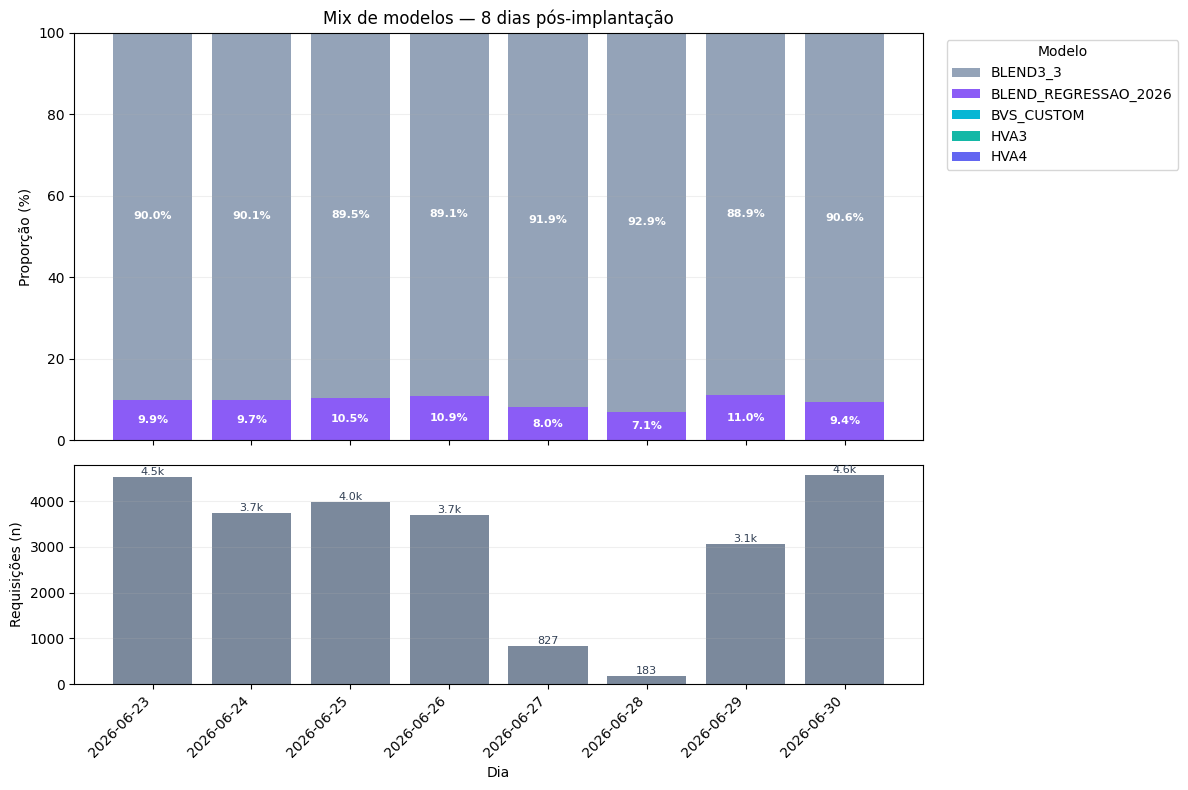

In [18]:
plot_daily_mix(
    df_daily,
    category_col="message_decisao",
    title=f"Mix de modelos — {WINDOW_DAYS} dias pós-implantação",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=1.0,
)

## Rating Json

In [19]:
# # Geral
# plot_daily_mix(
#     df_daily,
#     category_col="message_classificacao",
#     title=f"Mix de rating geral — {WINDOW_DAYS} dias pós-implantação",
#     category_order=RATING_ORDER,
#     color_map=RATING_COLOR_MAP,
#     text_color_map=RATING_TEXT_COLOR_MAP,
#     reverse_stack=True,
#     legend_title="Rating",
#     min_label_pct=3.0,
#     show_volume=False,
# )

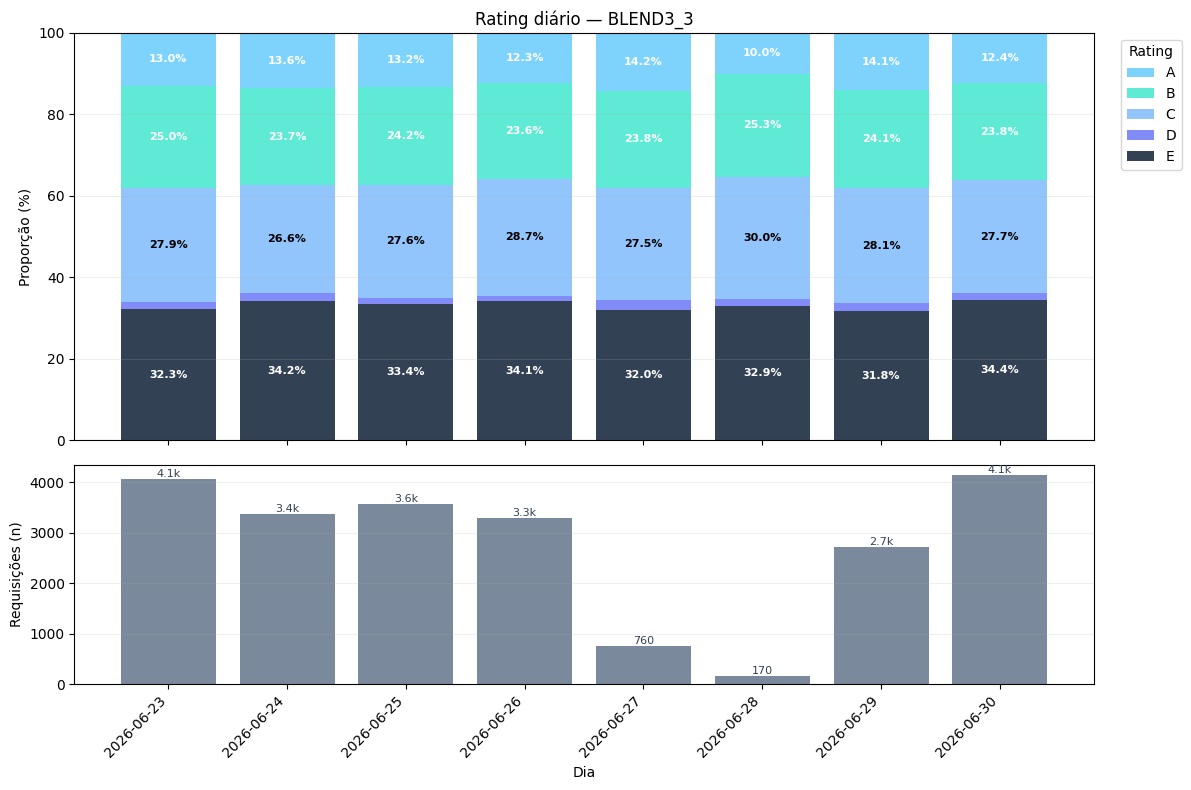

In [20]:
# Por modelo
for model in MODEL_ORDER_GRAPH:
    df_model = df_daily[df_daily["message_decisao"] == model]
    if df_model.empty:
        continue

    plot_daily_mix(
        df_model,
        category_col="message_classificacao",
        title=f"Rating diário — {model}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        legend_title="Rating",
        min_label_pct=5.0,
    )

# Avaliação Semanal

In [21]:
WINDOW_WEEKS = 6

df_weekly = filter_monitoring_week_window(
    df,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)
print(f"Semanas: {df_weekly['year_week'].nunique()} | Volume: {len(df_weekly):,}")
print(f"Período: {df_weekly['requested_at'].min()} → {df_weekly['requested_at'].max()}")

Semanas: 5 | Volume: 85,279
Período: 2026-06-03 00:00:00 → 2026-06-30 00:00:00


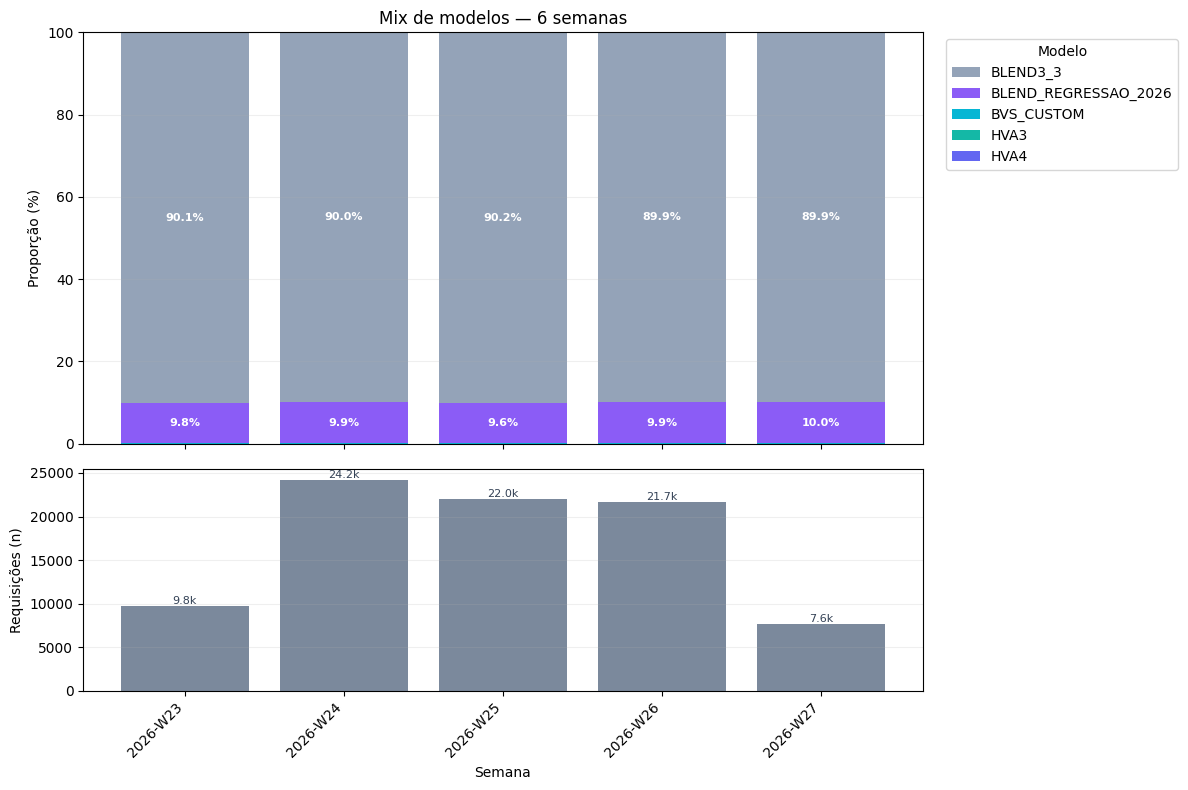

In [22]:
# Geral — modelos
plot_weekly_mix(
    df_weekly,
    category_col="message_decisao",
    title=f"Mix de modelos — {WINDOW_WEEKS} semanas",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

In [23]:
# plot_weekly_mix(
#     df_weekly,
#     category_col="message_classificacao",
#     title=f"Mix de rating geral — {WINDOW_WEEKS} semanas pós-implantação",
#     category_order=RATING_ORDER,
#     color_map=RATING_COLOR_MAP,
#     text_color_map=RATING_TEXT_COLOR_MAP,
#     reverse_stack=True,
#     legend_title="Rating",
#     min_label_pct=3.0,
#     show_volume=False,
# )

## Mix de Rating Geral

In [24]:
# plot_weekly_mix(
#     df_weekly,
#     category_col="message_classificacao",
#     title=f"Rating semanal — Total",
#     category_order=RATING_ORDER,
#     color_map=RATING_COLOR_MAP,
#     text_color_map=RATING_TEXT_COLOR_MAP,
#     reverse_stack=True,
#     legend_title="Rating",
#     min_label_pct=5.0,
#     show_volume=False,
# )

## Mix de Rating por Modelo

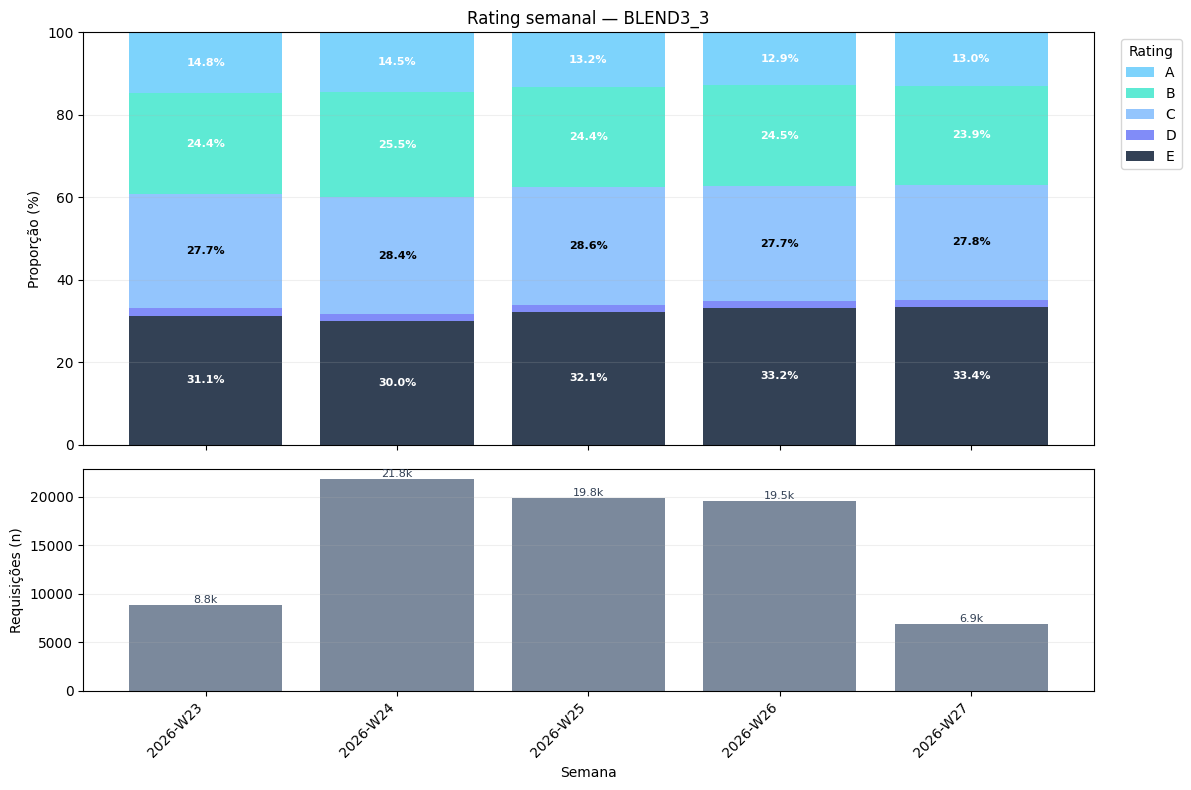

In [25]:
for model in MODEL_ORDER_GRAPH:
    df_model = df_weekly[df_weekly["message_decisao"] == model]
    if df_model.empty:
        continue

    plot_weekly_mix(
        df_model,
        category_col="message_classificacao",
        title=f"Rating semanal — {model}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        legend_title="Rating",
        min_label_pct=5.0,
    )

# Escoragem Manual

## Score

In [26]:
df_blend4 = df[df['message_decisao'].isin(['BLEND3_3'])]

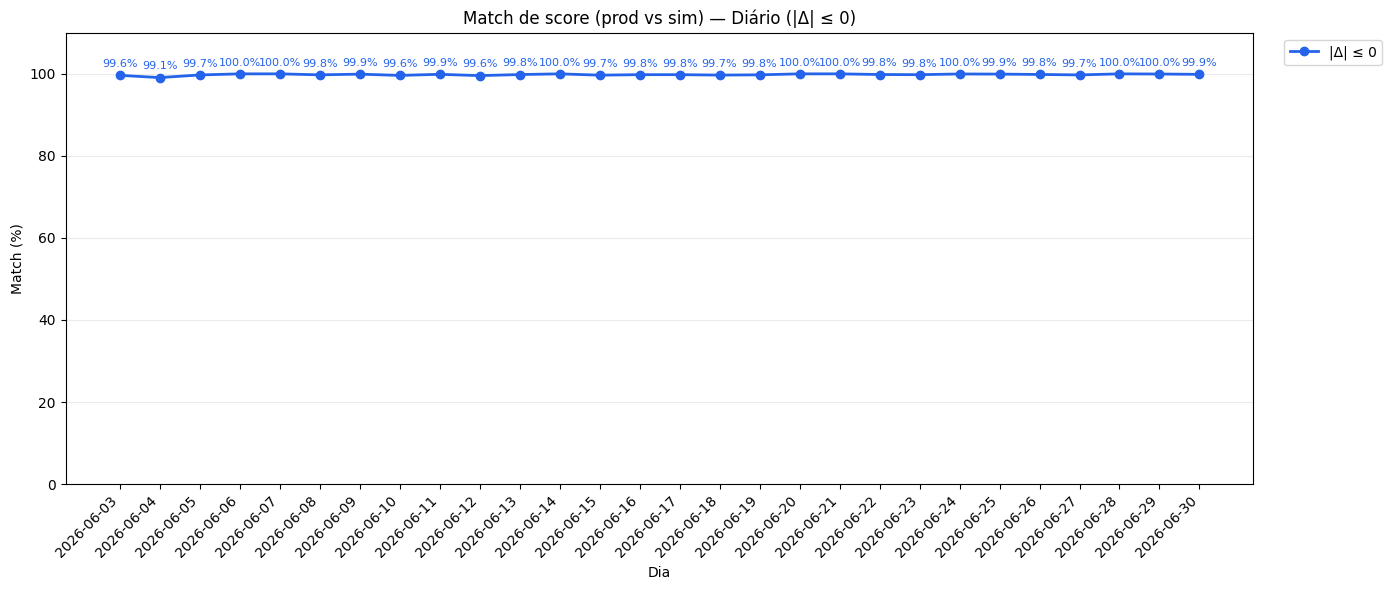

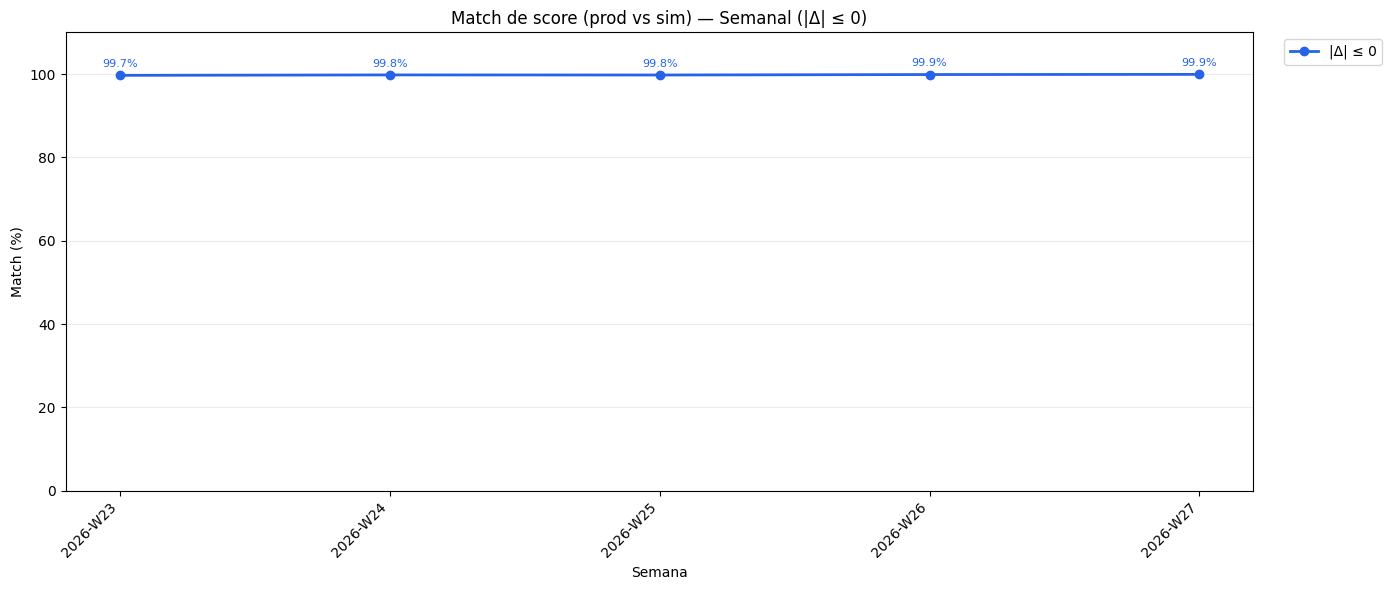

In [27]:
# Tabelas (como o score_summary que você já usa, mas por período)
daily_summary, weekly_summary = plot_score_match_monitoring(
    df_blend4,
    production_score_col="message_blendRegressaoPredict",
    simulated_score_col="predict_blend3_2_to_score",
    model_col=None,          # geral; use "message_decisao" para linha por modelo
    match_tolerance=0,      # coluna pct_match_abs_le_10
    show_volume=False,
    ylim=(0, 110)
)

In [28]:
daily_summary[["period", "volume_total", "pct_match_abs_le_10", "score_abs_diff_mean"]]

,period,volume_total,pct_match_abs_le_10,score_abs_diff_mean
0,2026-06-03,4146.0,99.86,0.1
1,2026-06-04,440.0,99.55,0.2
2,2026-06-05,3340.0,99.94,0.0
3,2026-06-06,744.0,100.00,0.0
4,2026-06-07,132.0,100.00,0.0
5,2026-06-08,4898.0,99.90,0.0
6,2026-06-09,5866.0,100.00,0.0
7,2026-06-10,3927.0,99.85,0.0
8,2026-06-11,3559.0,99.94,0.0
9,2026-06-12,2781.0,99.89,0.0


## Rating

## Comparação Rating Escoragem Manual

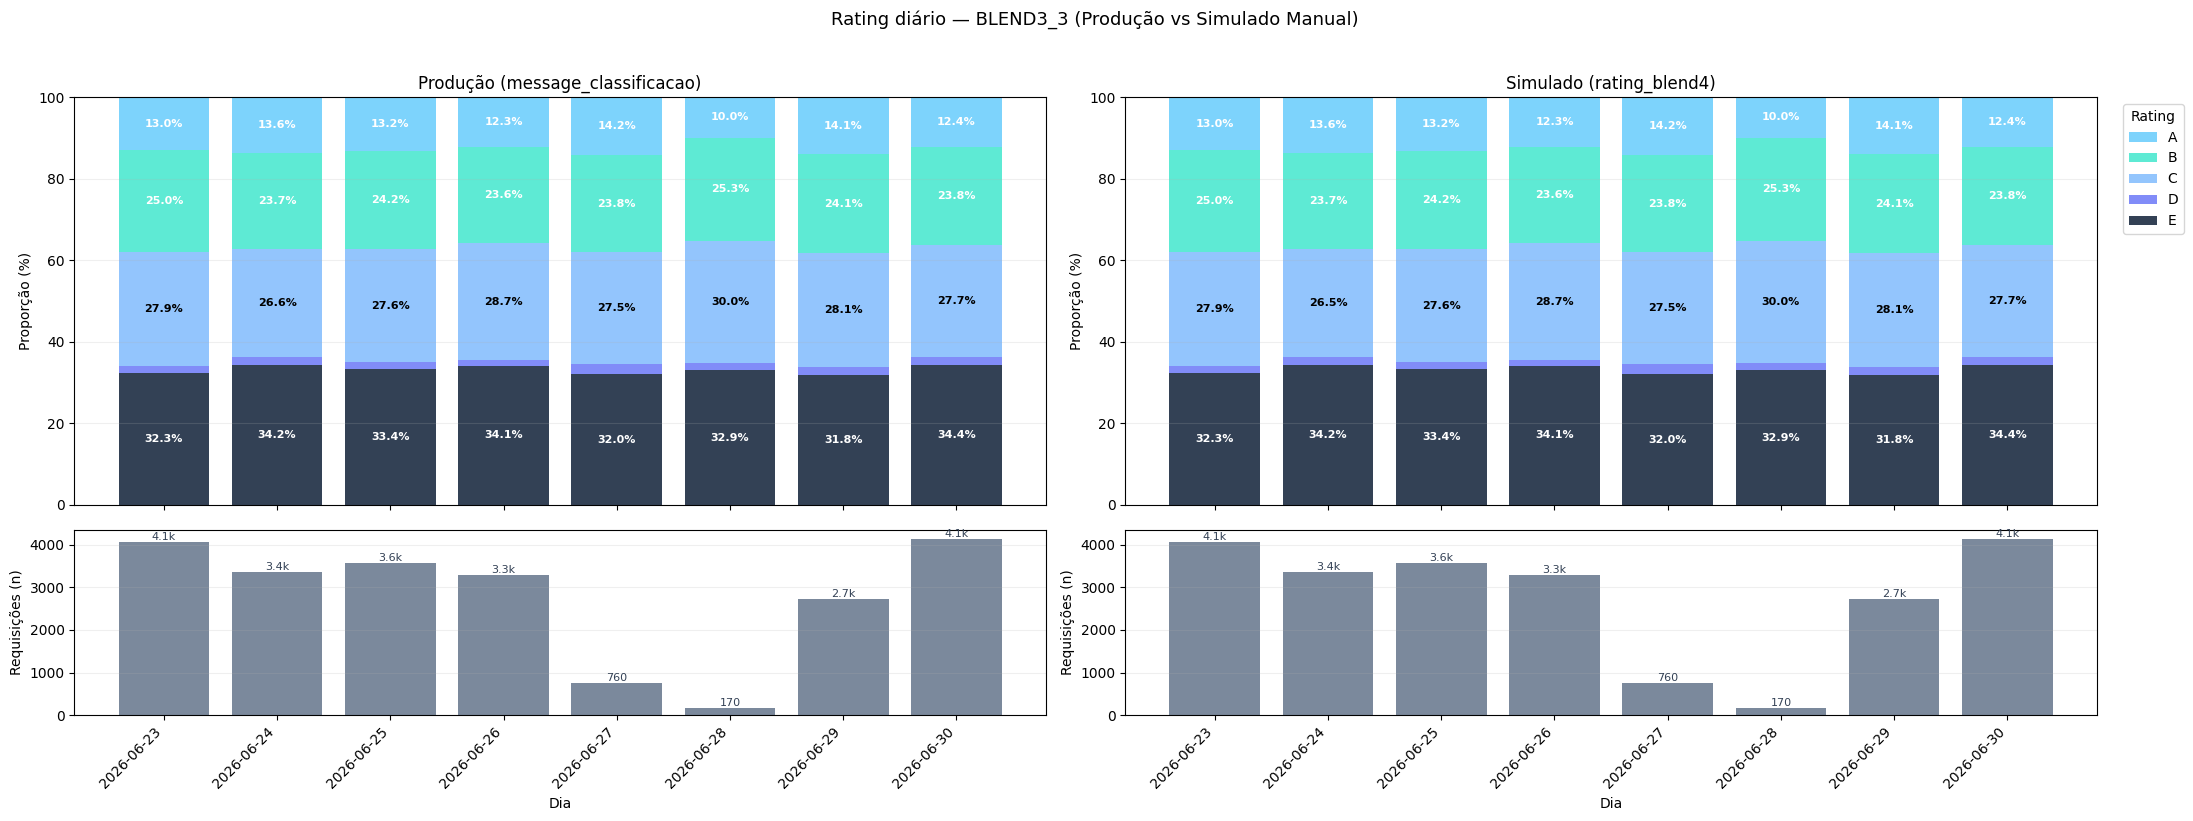

In [29]:
MODELS = ["BLEND3_3"]

for model in MODELS:
    df_model = df_daily[df_daily["message_decisao"] == model]

    plot_daily_rating_comparison(
        df_model,
        title=f"Rating diário — {model} (Produção vs Simulado Manual)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_manual_blend3",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

In [30]:
for model in MODELS:
    pivot = pd.crosstab(
        df_daily.loc[df_daily["message_decisao"] == model, "message_classificacao"],
        df_daily.loc[df_daily["message_decisao"] == model, "rating_manual_blend3"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND3_3


rating_manual_blend3,A,B,C,D,E,All
message_classificacao,,,,,,
A,2875,0,0,0,0,2875
B,0,5316,0,0,0,5316
C,0,0,6120,2,0,6122
D,0,0,0,386,0,386
E,0,0,0,0,7361,7361
All,2875,5316,6120,388,7361,22060


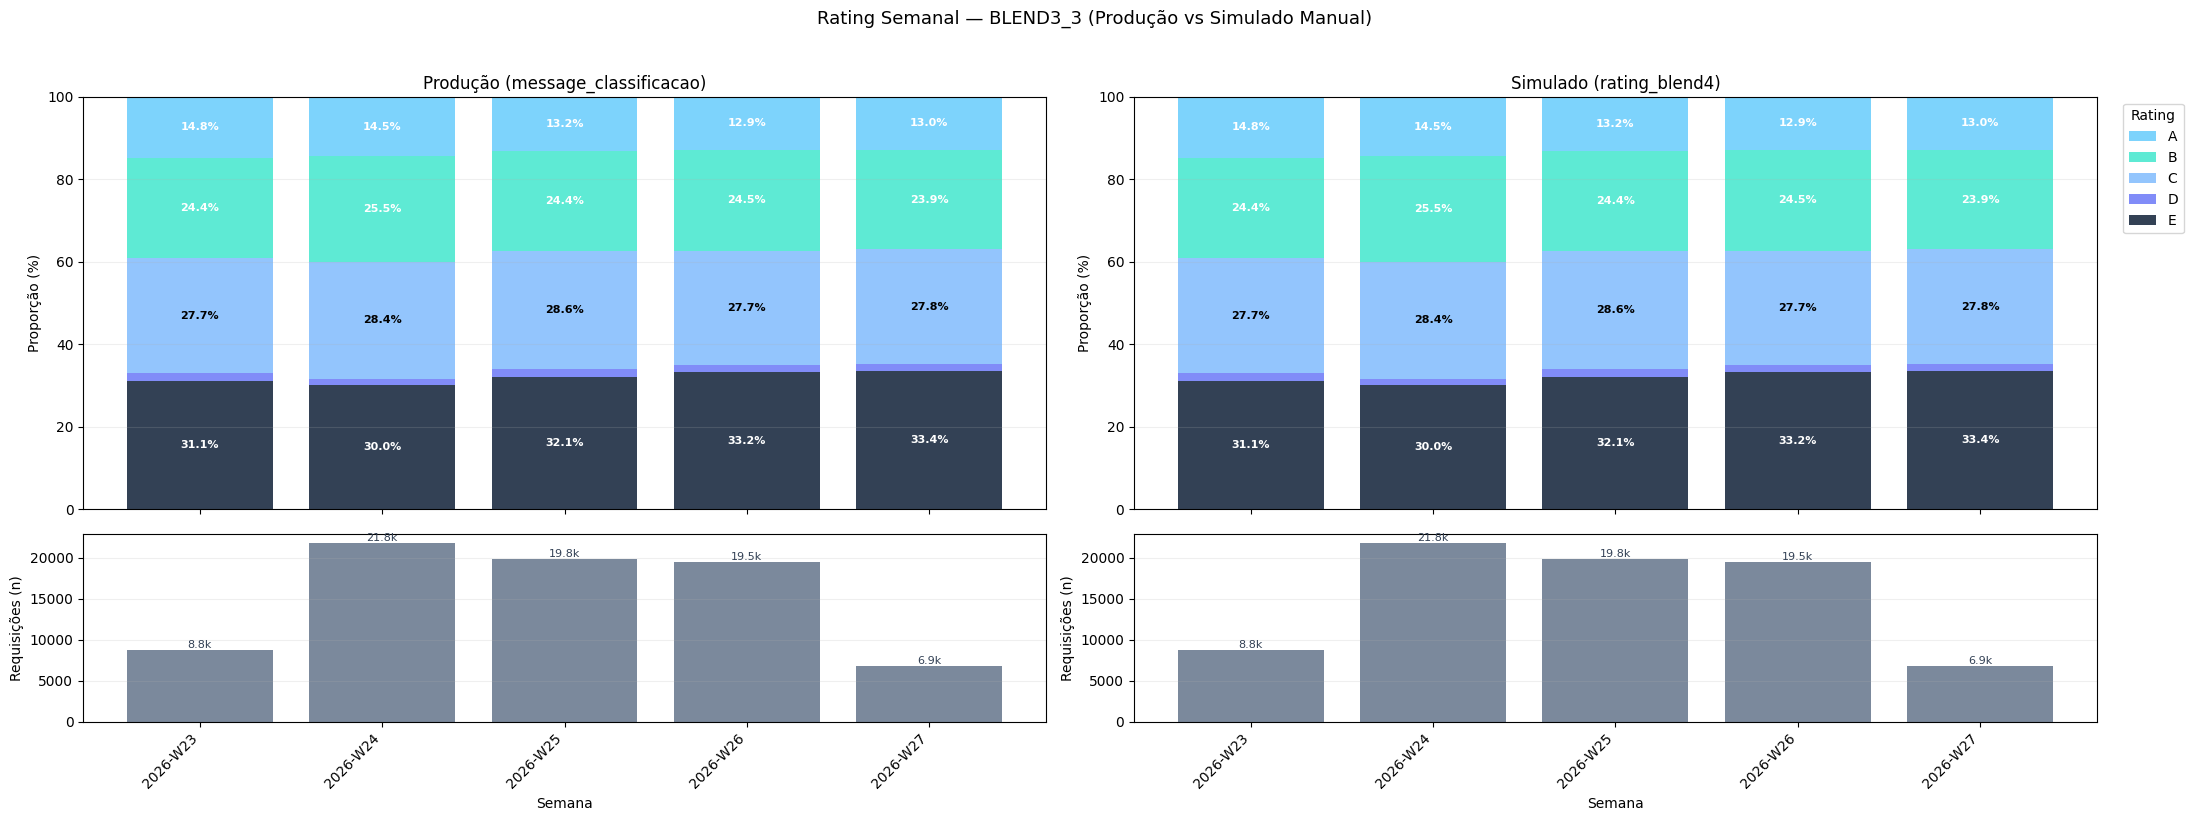

In [31]:
MODELS = ["BLEND3_3"]

for model in MODELS:
    df_model = df_weekly[df_weekly["message_decisao"] == model]

    plot_weekly_rating_comparison(
        df_model,
        title=f"Rating Semanal — {model} (Produção vs Simulado Manual)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_manual_blend3",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

In [32]:
for model in MODELS:
    pivot = pd.crosstab(
        df_weekly.loc[df_weekly["message_decisao"] == model, "message_classificacao"],
        df_weekly.loc[df_weekly["message_decisao"] == model, "rating_manual_blend3"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND3_3


rating_manual_blend3,A,B,C,D,E,All
message_classificacao,,,,,,
A,10486,0,0,0,0,10486
B,0,18955,1,0,0,18956
C,0,0,21624,4,0,21628
D,0,0,0,1321,0,1321
E,0,0,0,0,24401,24401
All,10486,18955,21625,1325,24401,76792


## Comparação Rating Json
A questão aqui é se o message_classificacao está vindo correto, ou seja, se os cortes estão sendo feitos corretamente.

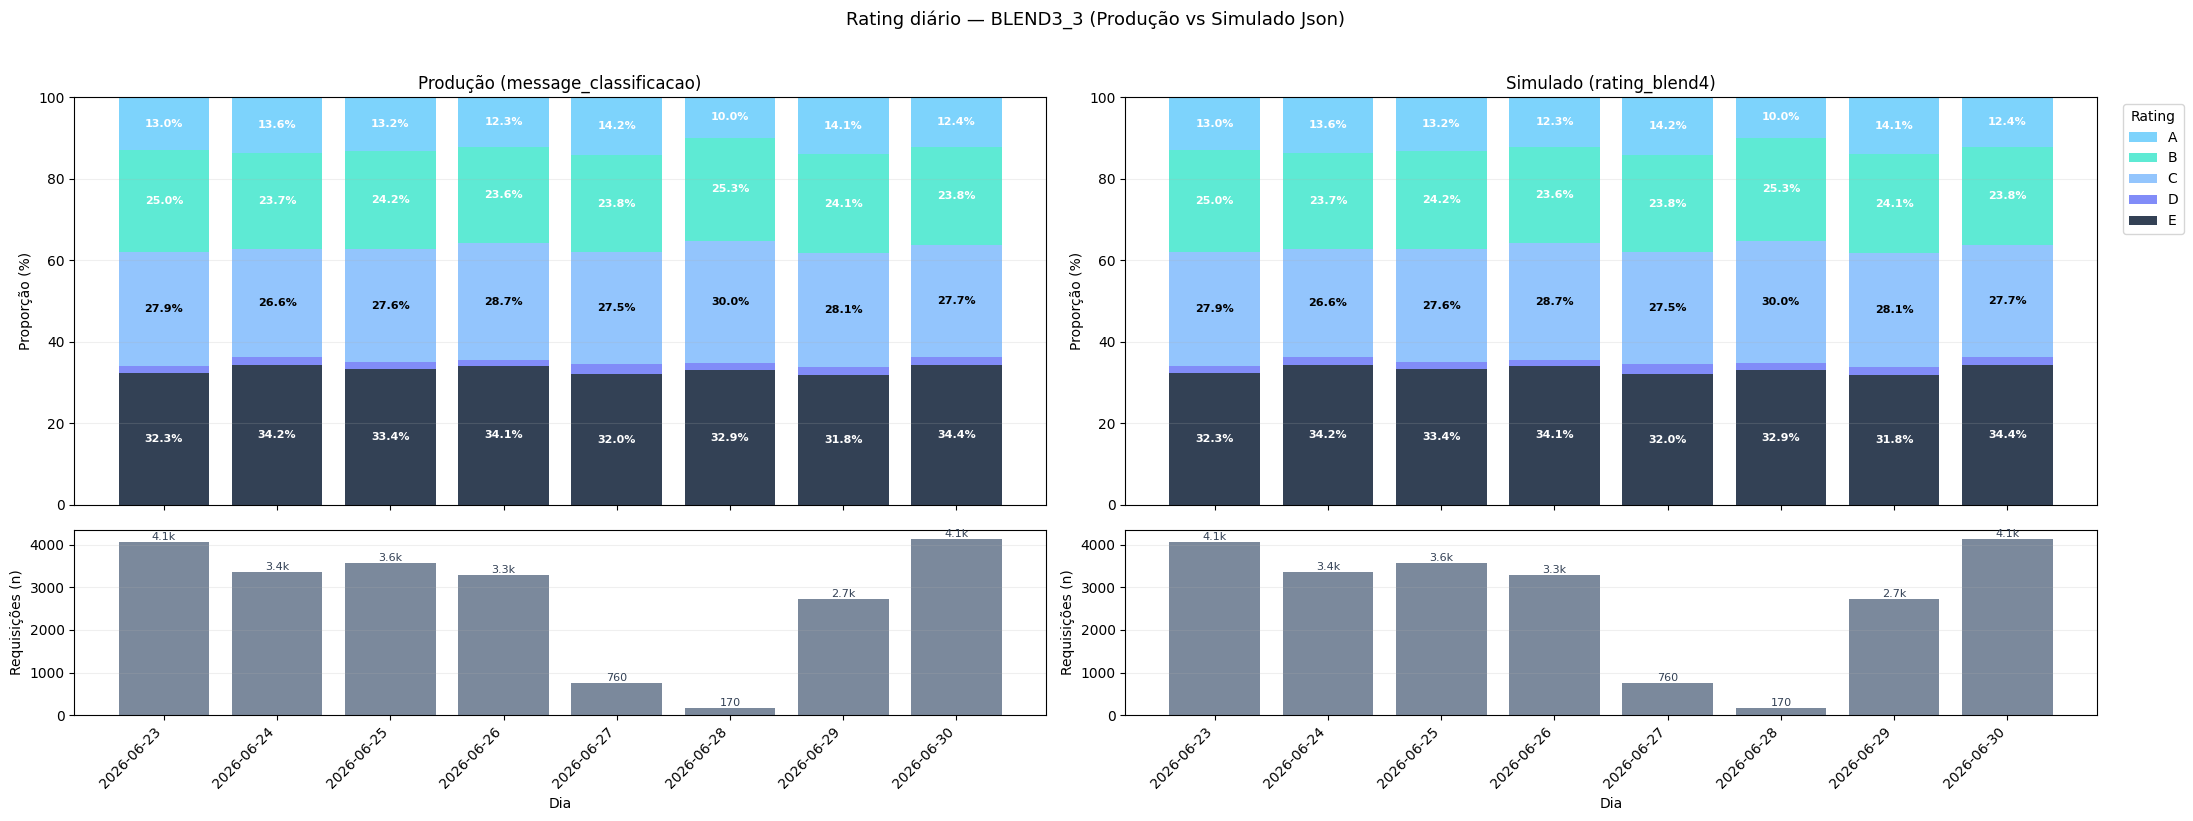

In [33]:
MODELS = ["BLEND3_3"]

for model in MODELS:
    df_model = df_daily[df_daily["message_decisao"] == model]

    plot_daily_rating_comparison(
        df_model,
        title=f"Rating diário — {model} (Produção vs Simulado Json)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_json_blend3",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

In [34]:
for model in MODELS:
    pivot = pd.crosstab(
        df_daily.loc[df_daily["message_decisao"] == model, "message_classificacao"],
        df_daily.loc[df_daily["message_decisao"] == model, "rating_json_blend3"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND3_3


rating_json_blend3,A,B,C,D,E,All
message_classificacao,,,,,,
A,2875,0,0,0,0,2875
B,0,5316,0,0,0,5316
C,0,0,6122,0,0,6122
D,0,0,0,386,0,386
E,0,0,0,0,7361,7361
All,2875,5316,6122,386,7361,22060


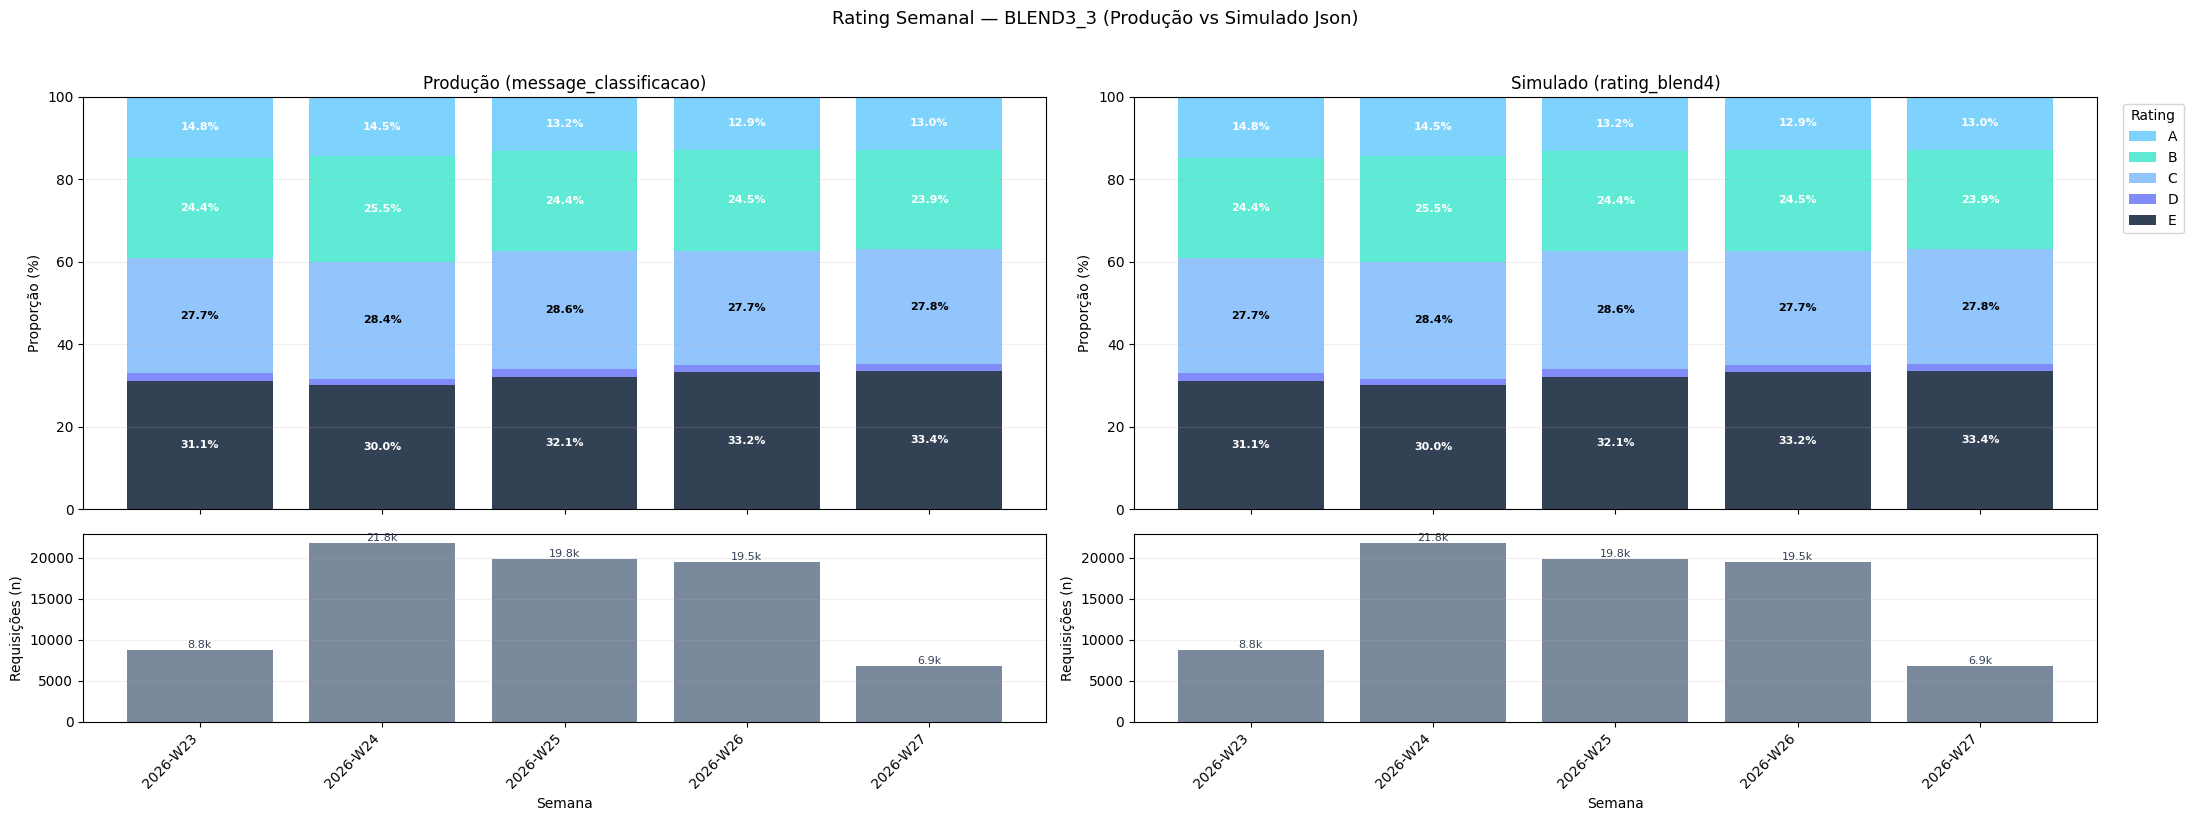

In [35]:
MODELS = ["BLEND3_3"]

for model in MODELS:
    df_model = df_weekly[df_weekly["message_decisao"] == model]

    plot_weekly_rating_comparison(
        df_model,
        title=f"Rating Semanal — {model} (Produção vs Simulado Json)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_json_blend3",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

In [36]:
for model in MODELS:
    pivot = pd.crosstab(
        df_weekly.loc[df_weekly["message_decisao"] == model, "message_classificacao"],
        df_weekly.loc[df_weekly["message_decisao"] == model, "rating_json_blend3"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND3_3


rating_json_blend3,A,B,C,D,E,All
message_classificacao,,,,,,
A,10486,0,0,0,0,10486
B,0,18956,0,0,0,18956
C,0,0,21628,0,0,21628
D,0,0,0,1321,0,1321
E,0,0,0,0,24401,24401
All,10486,18956,21628,1321,24401,76792


## PSI

In [37]:
model_vars = [
    "SCRCRDPNMGRLPFLGBCLFCREDPGV1__normalized3_2",
    "SERASA_HVA4__normalized3_2",
    "age__normalized3_2",
    "property_type",
    "qtde_restricoes__consulta_realizada__normalized3_2",
    "income_commitment__normalized3_2",
    "agency_pc4_mais_100_contratos__pc_categorias__normalized3_2",
    "city_pc4_mais_100_contratos__pc_categorias__normalized3_2",
    "flag_tem__contratos_anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null",
    "city_pc4_mais_100_contratos__pc_categorias_is_null",
    # "predict_blend3_2_to_score"
]

In [38]:
VARIABLE_LABELS = {
    "SCRCRDPNMGRLPFLGBCLFCREDPGV1__normalized3_2": "Score BVS",
    "SERASA_HVA4__normalized3_2": "Score Serasa HVA4",
    "age__normalized3_2": "Idade",
    "property_type": "Tipo de imóvel",
    "qtde_restricoes__consulta_realizada__normalized3_2": "Qtd. restrições",
    "income_commitment__normalized3_2": "Comprometimento de renda",
    "agency_pc4_mais_100_contratos__pc_categorias__normalized3_2": "PC categorias — agência (100+ contratos)",
    "city_pc4_mais_100_contratos__pc_categorias__normalized3_2": "PC categorias — cidade (100+ contratos)",
    "flag_tem__contratos_anteriores": "Tem contratos anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores": "Boleto atrasado (contratos anteriores)",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null": "PC categorias agência — nulo",
    "city_pc4_mais_100_contratos__pc_categorias_is_null": "PC categorias cidade — nulo",
    "predict_blend3_2_to_score": "Score Blend Regressão",
}

In [39]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend3_psi_reference.pkl"
# PSI_BASELINE_PATH = ANALYTICS_DIR / "blend4_psi_baseline_ref.csv"

psi_reference_artifact = load_psi_reference(PSI_REFERENCE_PATH)
# psi_baseline_ref = pd.read_csv(PSI_BASELINE_PATH)

In [40]:
daily_blend4 = df_daily[df_daily["message_decisao"] == "BLEND3_3"].copy()
weekly_blend4 = df_weekly[df_weekly["message_decisao"] == "BLEND3_3"].copy()

psi_daily = monitor_daily_psi(
    df_production=daily_blend4,
    artifact=psi_reference_artifact,
    date_col="requested_at",
    # baseline_ref=psi_baseline_ref,
    variables=model_vars,
)

psi_weekly = monitor_weekly_psi(
    df_production=weekly_blend4,
    artifact=psi_reference_artifact,
    # baseline_ref=psi_baseline_ref,
    variables=model_vars,
)

In [41]:
# target_day = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")
target_day = pd.to_datetime(daily_blend4["requested_at"]).max().strftime("%Y-%m-%d")
print(f"Target day: {target_day}")
df_day = daily_blend4[
    pd.to_datetime(daily_blend4["requested_at"]).dt.strftime("%Y-%m-%d") == target_day
]

psi_day = calculate_psi_table_from_reference(
    df_actual=df_day,
    artifact=psi_reference_artifact,
    comparison_label="production_vs_train",
    variables=model_vars,
)

psi_day

Target day: 2026-06-30


,variable,comparison,psi,status,n_actual
0,city_pc4_mais_100_contratos__pc_categorias__no...,production_vs_train,0.105320,moderate,4137
1,age__normalized3_2,production_vs_train,0.046566,stable,4137
2,income_commitment__normalized3_2,production_vs_train,0.044947,stable,4137
3,SCRCRDPNMGRLPFLGBCLFCREDPGV1__normalized3_2,production_vs_train,0.011648,stable,4137
4,city_pc4_mais_100_contratos__pc_categorias_is_...,production_vs_train,0.008055,stable,4137
5,agency_pc4_mais_100_contratos__pc_categorias__...,production_vs_train,0.007950,stable,4137
6,qtde_restricoes__consulta_realizada__normalize...,production_vs_train,0.007788,stable,4137
7,property_type,production_vs_train,0.004553,stable,4137
8,SERASA_HVA4__normalized3_2,production_vs_train,0.004541,stable,4137
9,agency_pc4_mais_100_contratos__pc_categorias_i...,production_vs_train,0.000978,stable,4137


In [42]:
week_order = (
    weekly_blend4[["year_week", "week_start"]]
    .drop_duplicates()
    .sort_values("week_start")["year_week"]
    .tolist()
)
week_order

['2026-W23', '2026-W24', '2026-W25', '2026-W26', '2026-W27']

In [43]:
# target_week = weekly_blend4.year_week.max()
# print(f"Target Week == {target_week} (Semana Corrente)")
# df_week = weekly_blend4[
#     weekly_blend4["year_week"] == target_week]

# psi_week = calculate_psi_table_from_reference(
#     df_actual=df_week,
#     artifact=psi_reference_artifact,
#     comparison_label="production_vs_train",
#     variables=model_vars,
# )

# psi_week.merge(psi_baseline_ref, on="variable", how="left")

In [45]:
target_week = target_week = week_order[-2]
print(f"Target Week == {target_week} (Semana Anterior Completa)")
df_week = weekly_blend4[
    weekly_blend4["year_week"] == target_week]

psi_week = calculate_psi_table_from_reference(
    df_actual=df_week,
    artifact=psi_reference_artifact,
    comparison_label="production_vs_train",
    variables=model_vars,
)

psi_week#.merge(psi_baseline_ref, on="variable", how="left")

Target Week == 2026-W26 (Semana Anterior Completa)


,variable,comparison,psi,status,n_actual
0,city_pc4_mais_100_contratos__pc_categorias__no...,production_vs_train,0.093909,stable,19510
1,age__normalized3_2,production_vs_train,0.038614,stable,19510
2,income_commitment__normalized3_2,production_vs_train,0.036508,stable,19510
3,SERASA_HVA4__normalized3_2,production_vs_train,0.009187,stable,19510
4,qtde_restricoes__consulta_realizada__normalize...,production_vs_train,0.007409,stable,19510
5,city_pc4_mais_100_contratos__pc_categorias_is_...,production_vs_train,0.005173,stable,19510
6,SCRCRDPNMGRLPFLGBCLFCREDPGV1__normalized3_2,production_vs_train,0.005105,stable,19510
7,agency_pc4_mais_100_contratos__pc_categorias__...,production_vs_train,0.004099,stable,19510
8,agency_pc4_mais_100_contratos__pc_categorias_i...,production_vs_train,0.001730,stable,19510
9,property_type,production_vs_train,0.001247,stable,19510


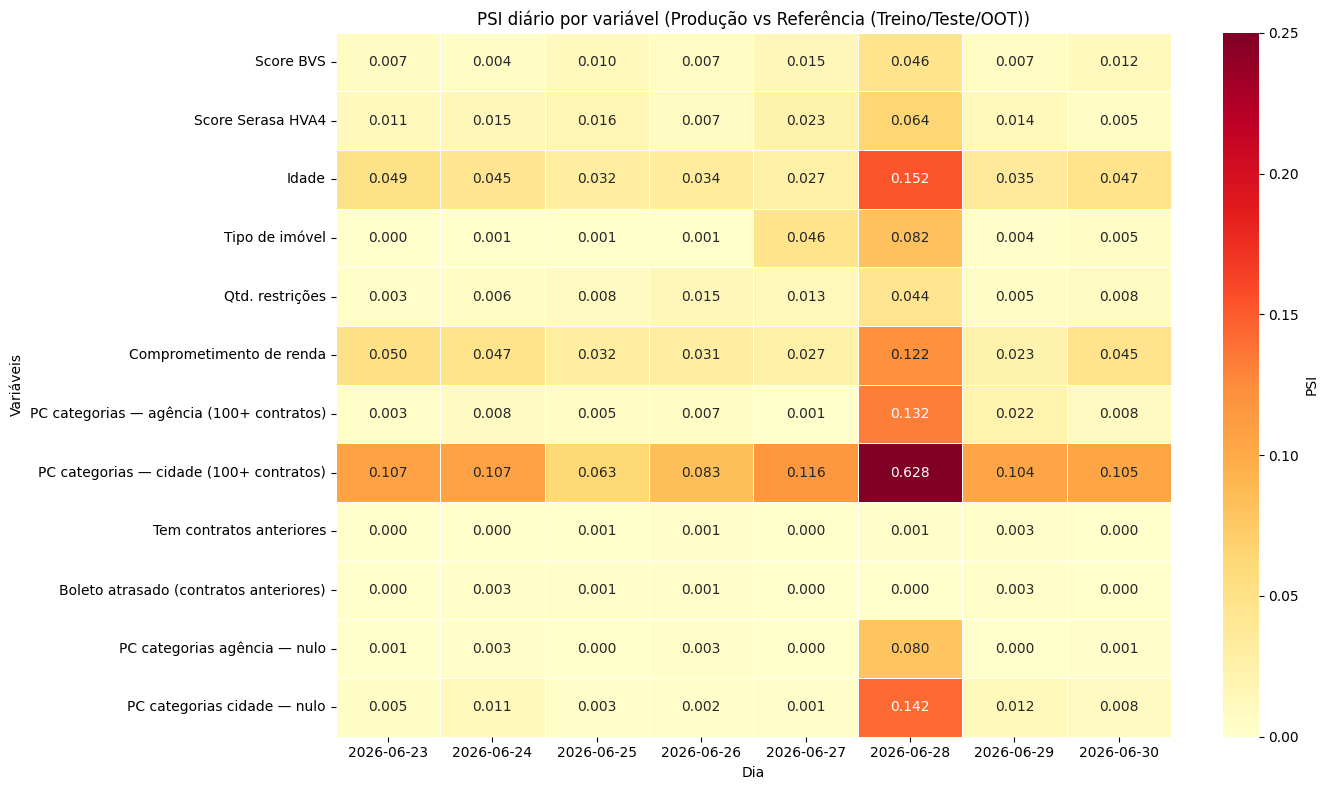

In [46]:
pivot = (
    psi_daily
    .pivot(index="variable", columns="monitoring_day", values="psi")
    .reindex(model_vars)
    .rename(index=VARIABLE_LABELS)
)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI diário por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Dia")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

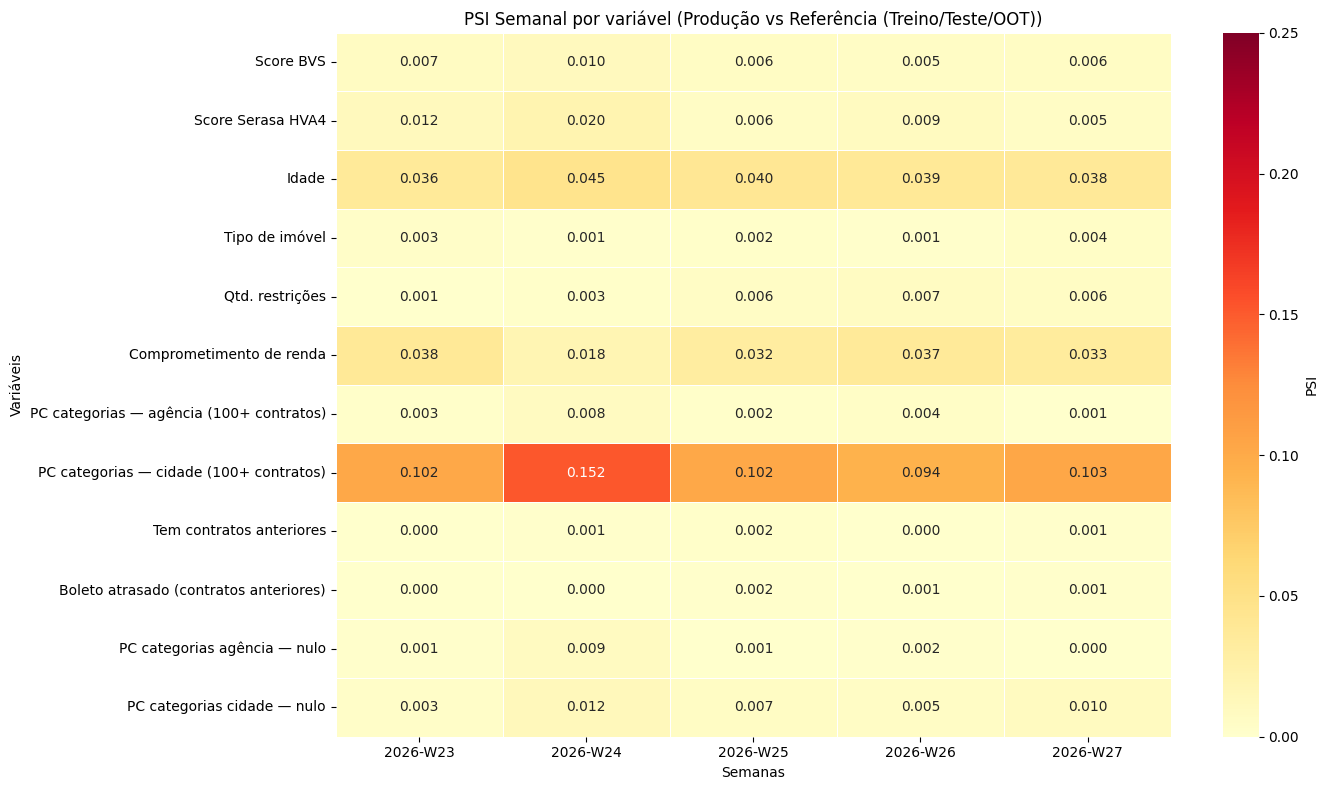

In [47]:
pivot = (
    psi_weekly
    .pivot(index="variable", columns="monitoring_week", values="psi")
    .reindex(index=model_vars, columns=week_order)
    .rename(index=VARIABLE_LABELS)
)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI Semanal por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Semanas")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

Trazer: Verificar se houve aumento real de aluguel

Tirar o 0 da Renda Serasa?
Acompanhar Renda e Score

Matriz por dia: Acompanhar preenchimento/valor especial. Percentual de Falha. Acompanhar Volume.

Acompanhar variável Renda (Serasa) e Aluguel
Investigar Comprometimento de Renda
Investigar variável PC cat cidades (Tabela Criação da PC das Cidades)

## PSI D-1

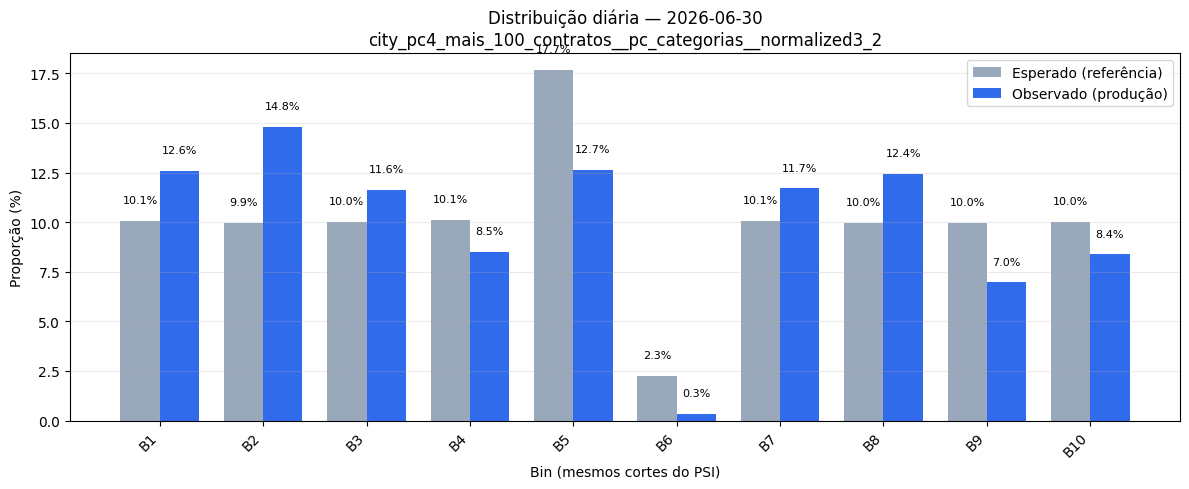

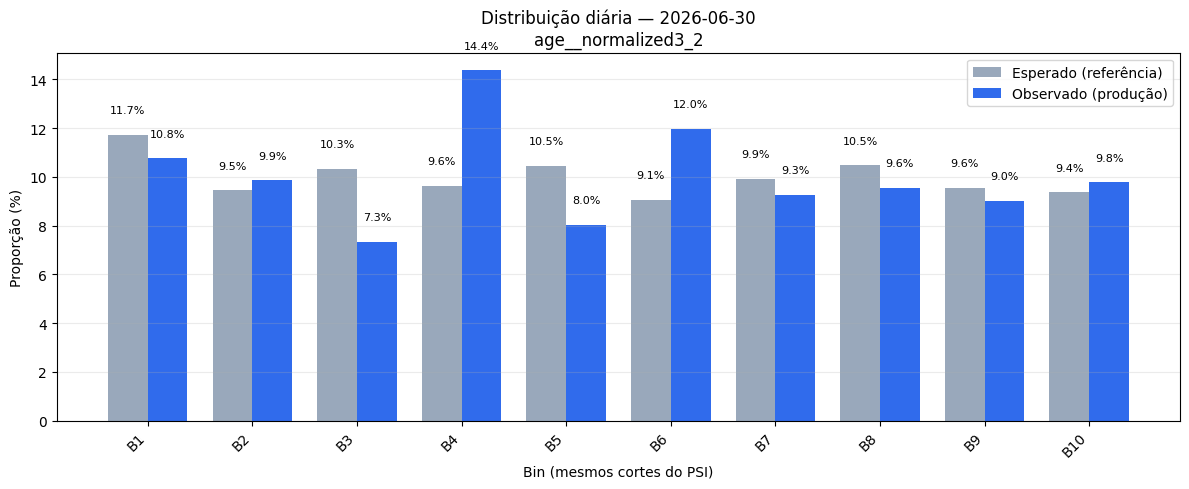

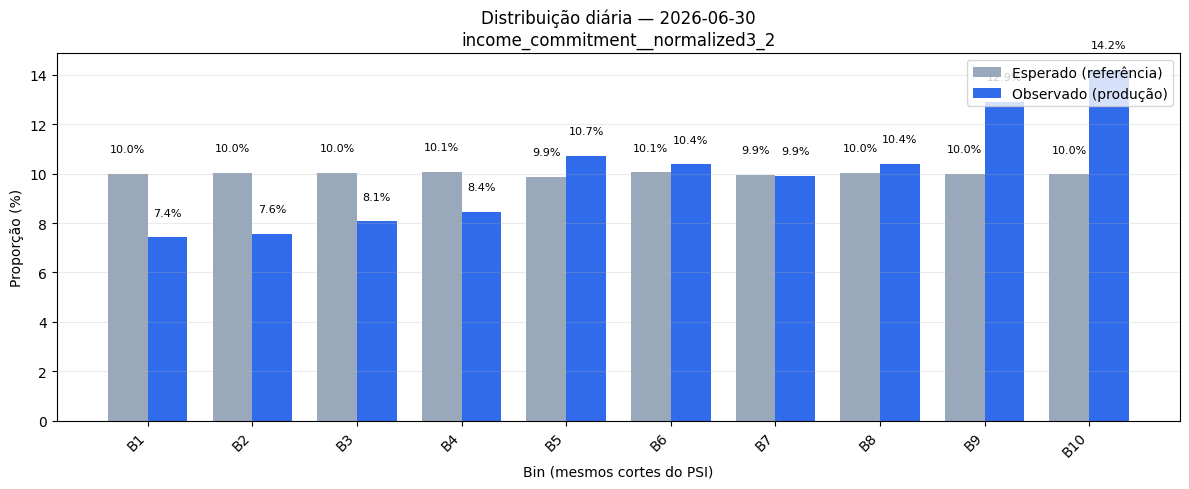

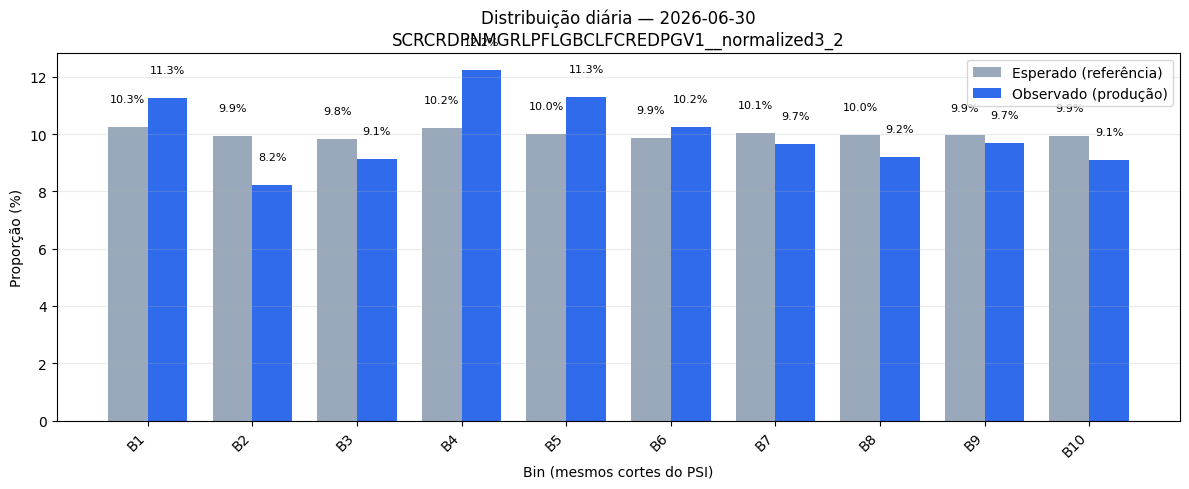

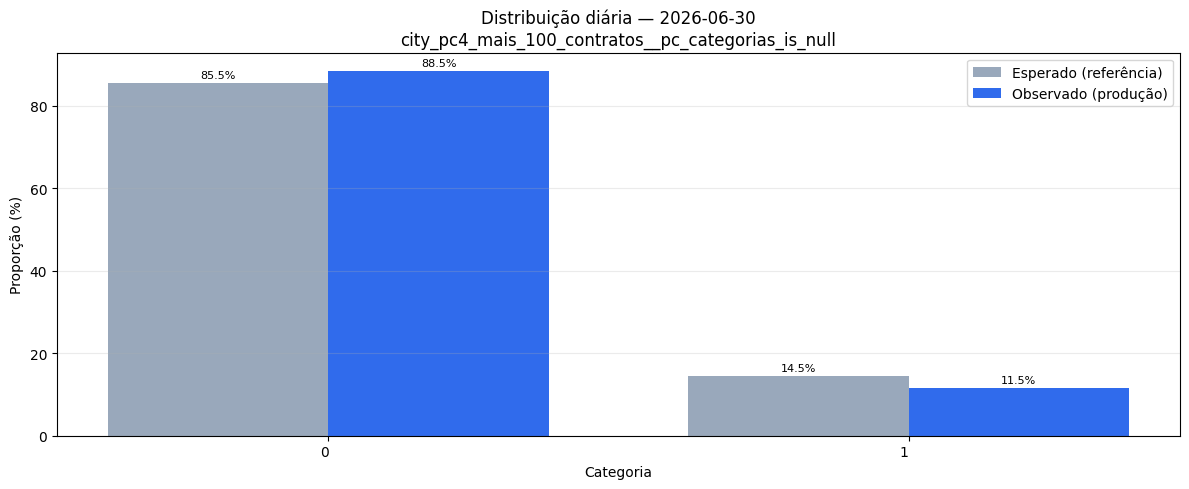

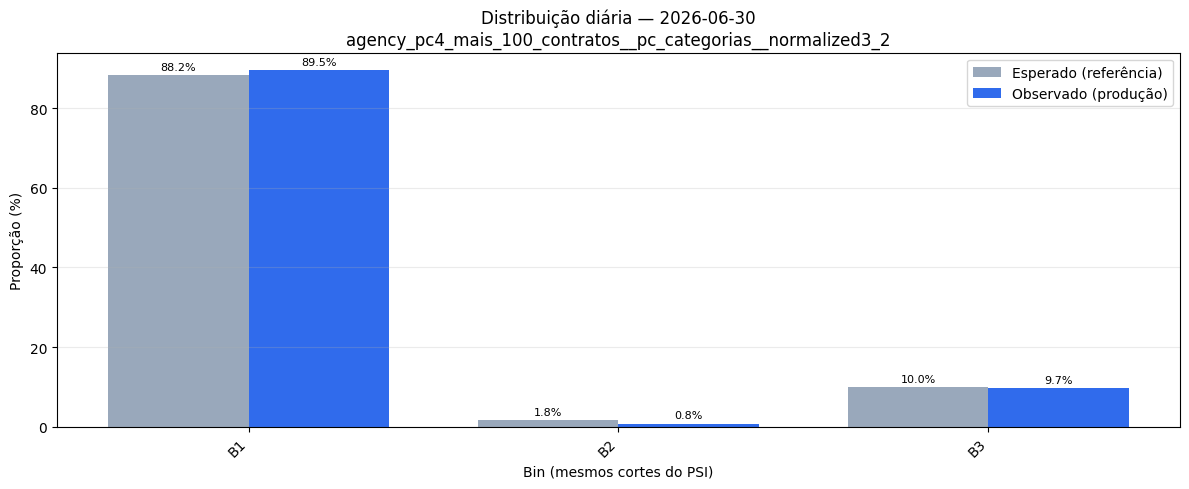

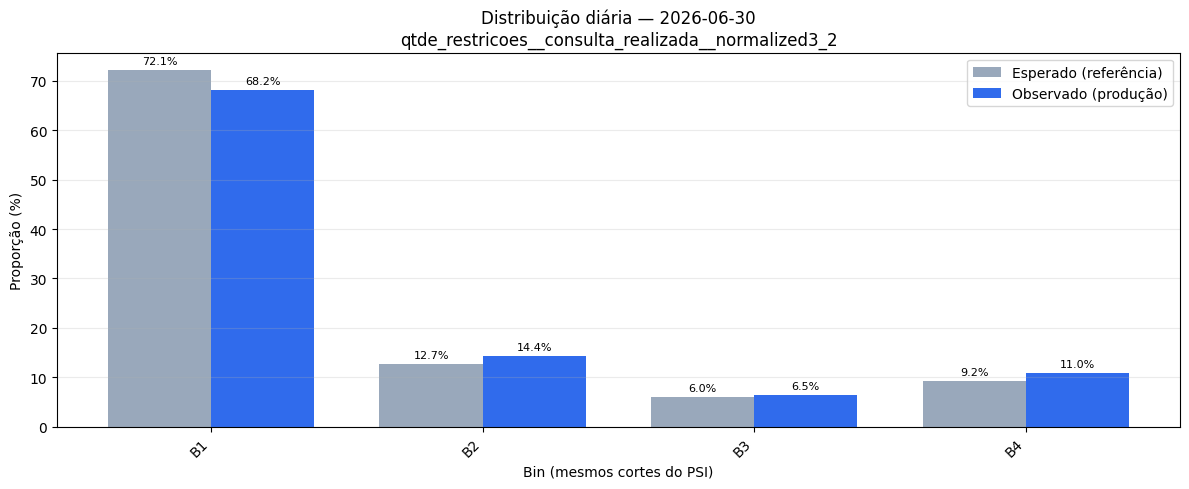

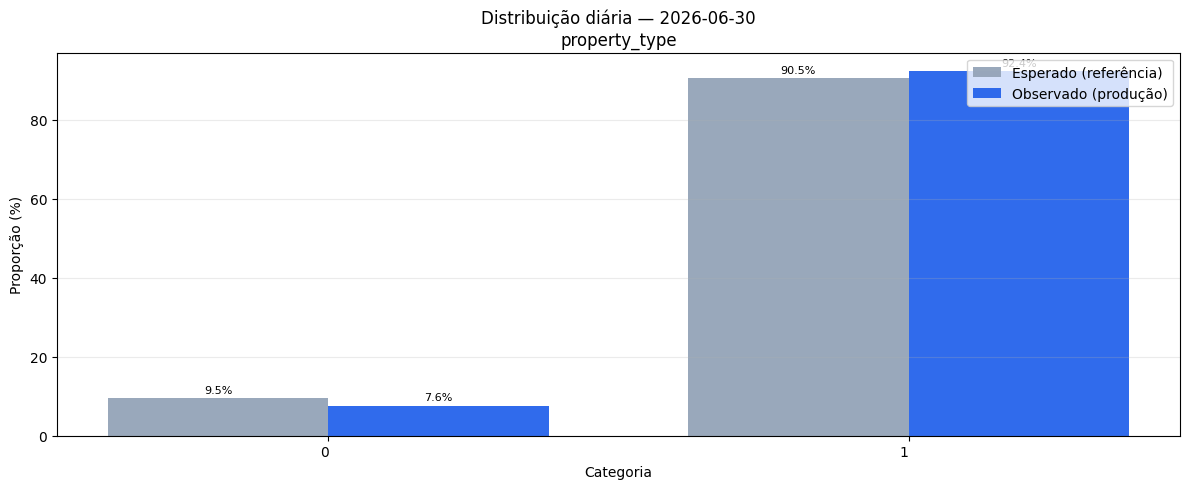

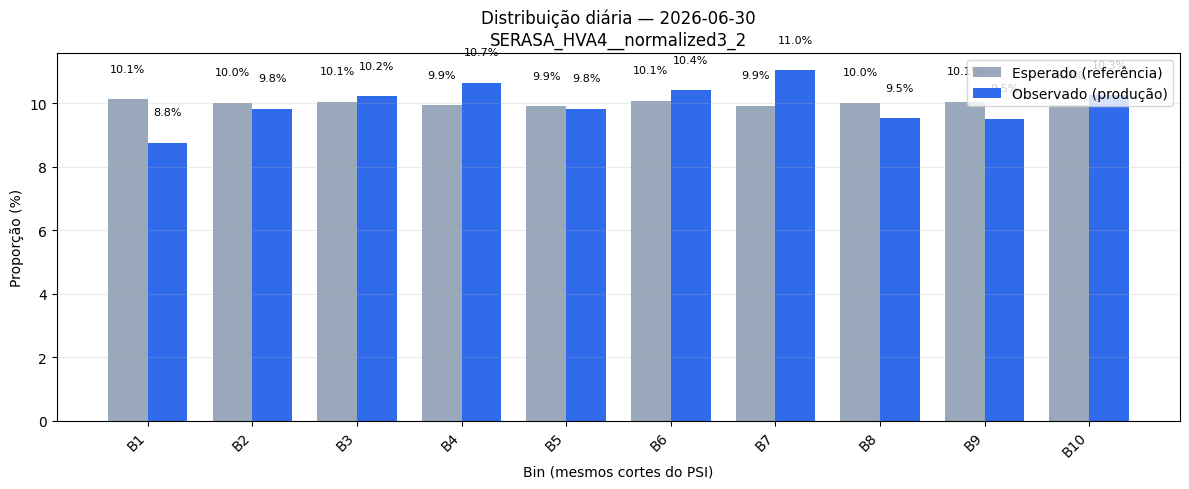

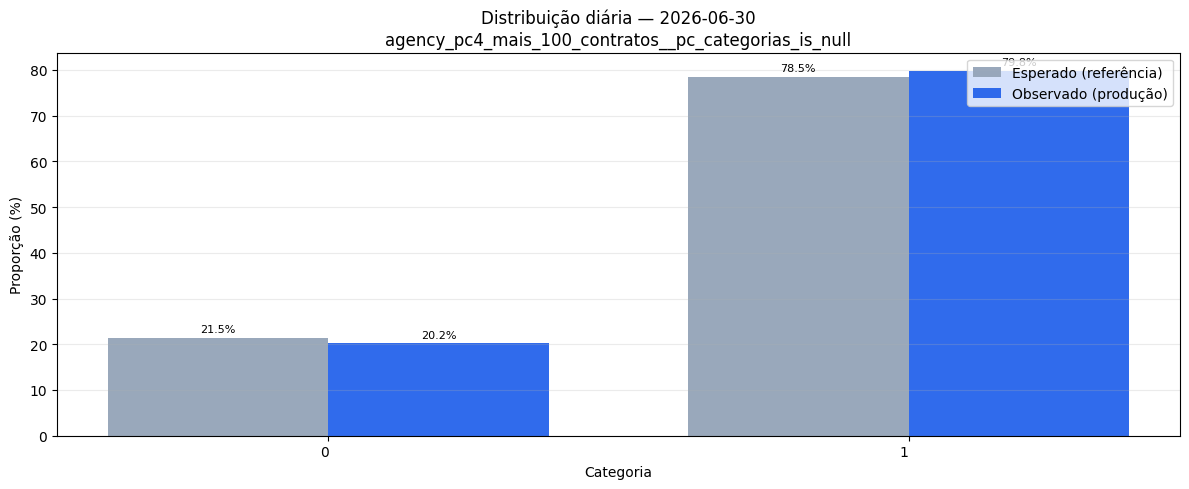

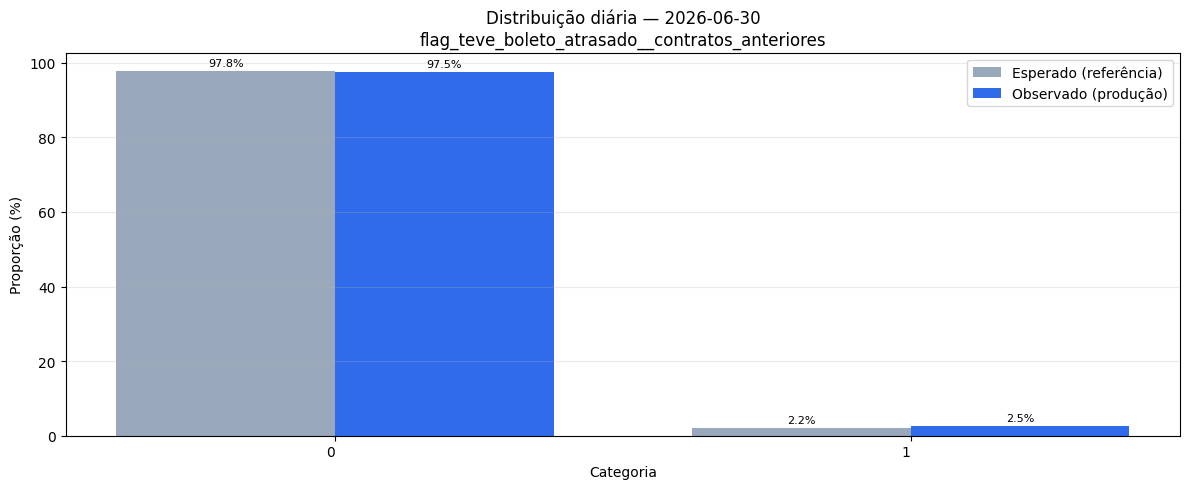

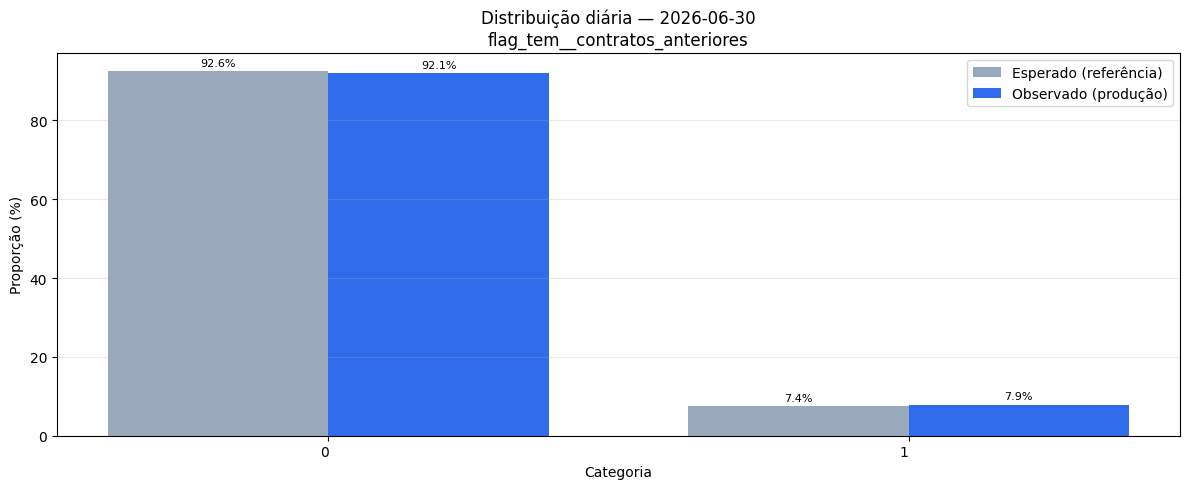

In [48]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_day,
    artifact=psi_reference_artifact,
    variables=model_vars,
    top_n=12,
    title_prefix=f"Distribuição diária — {target_day}",
)

## PSI Semanal W-1 (Última Semana Completa)

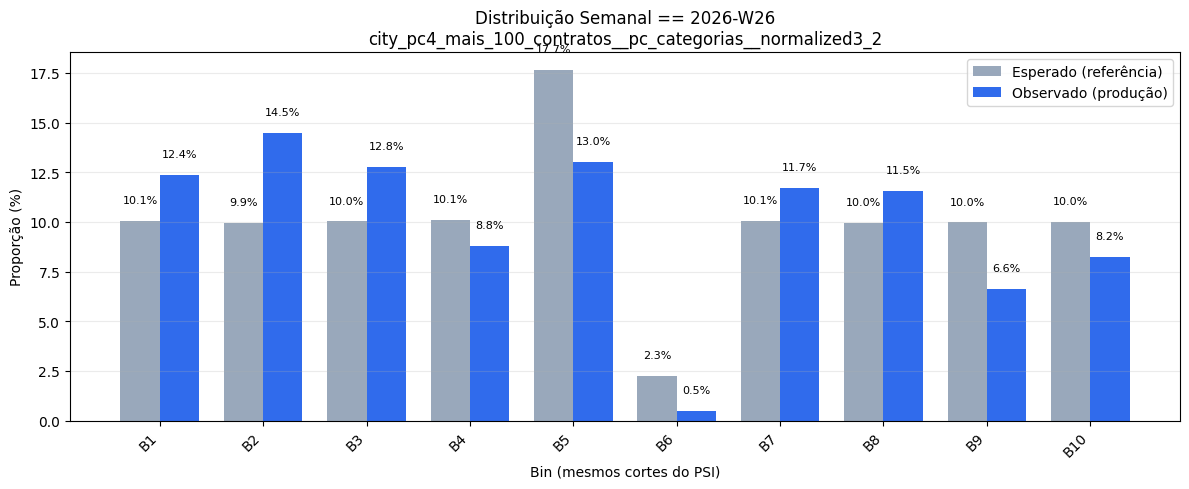

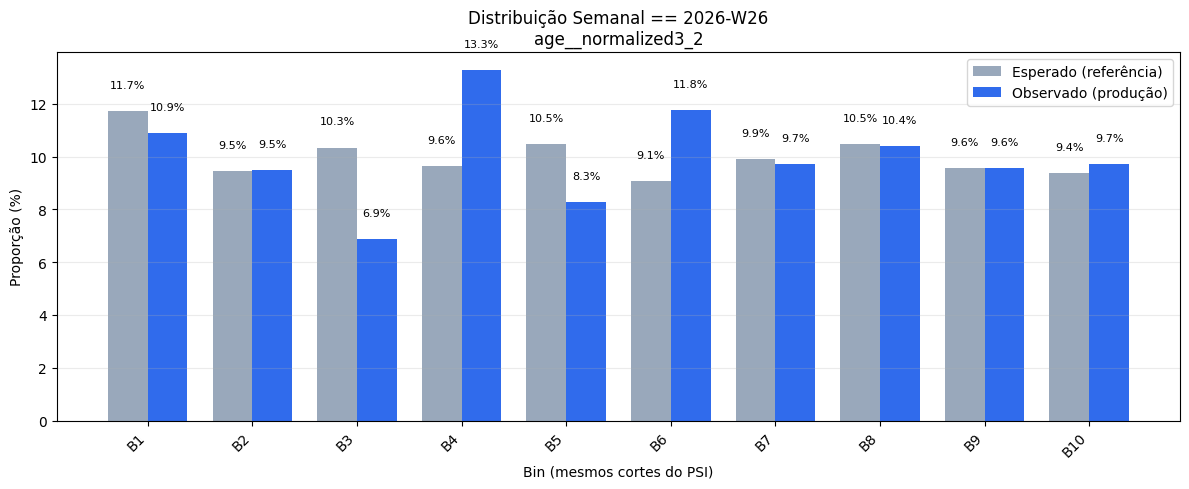

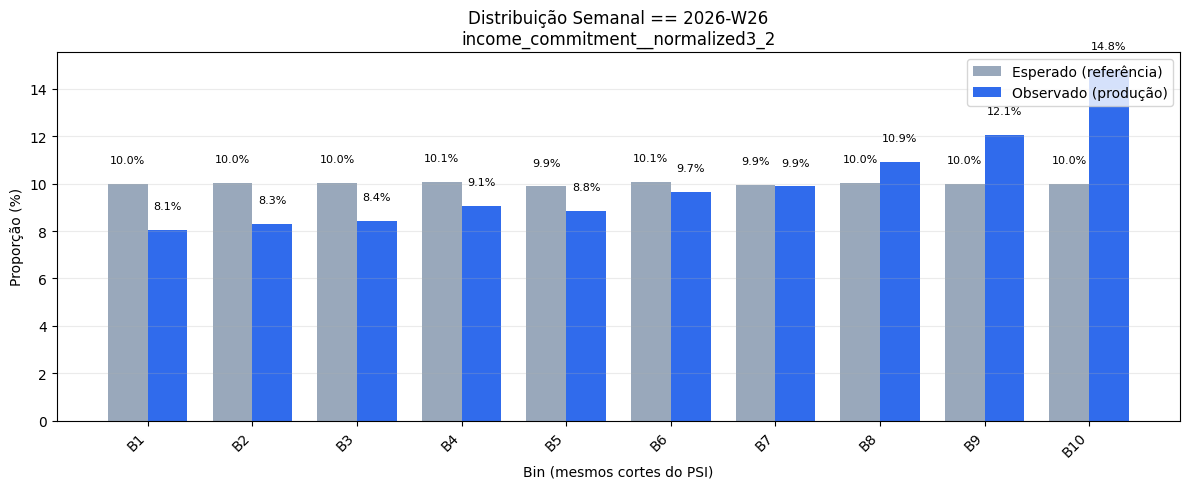

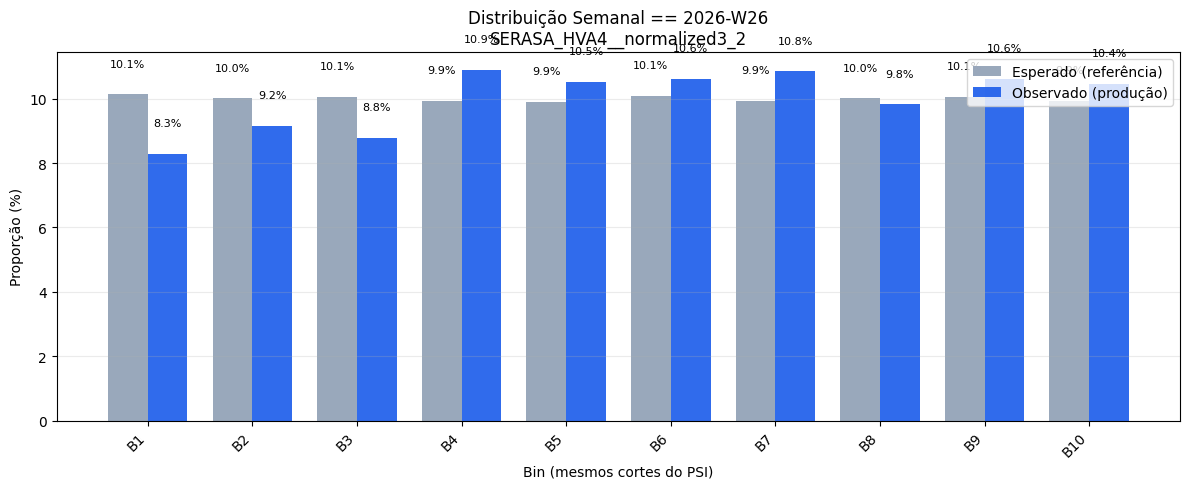

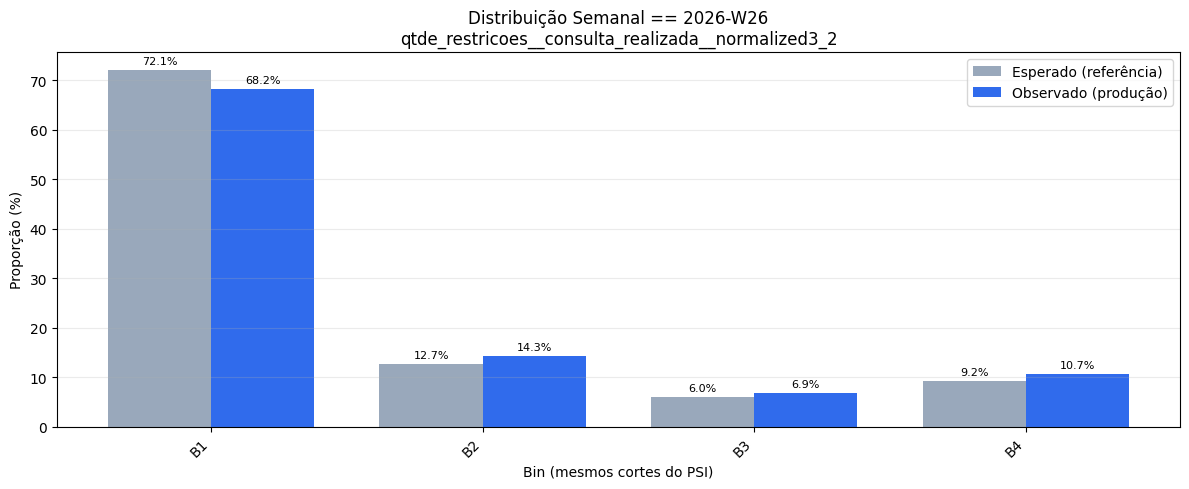

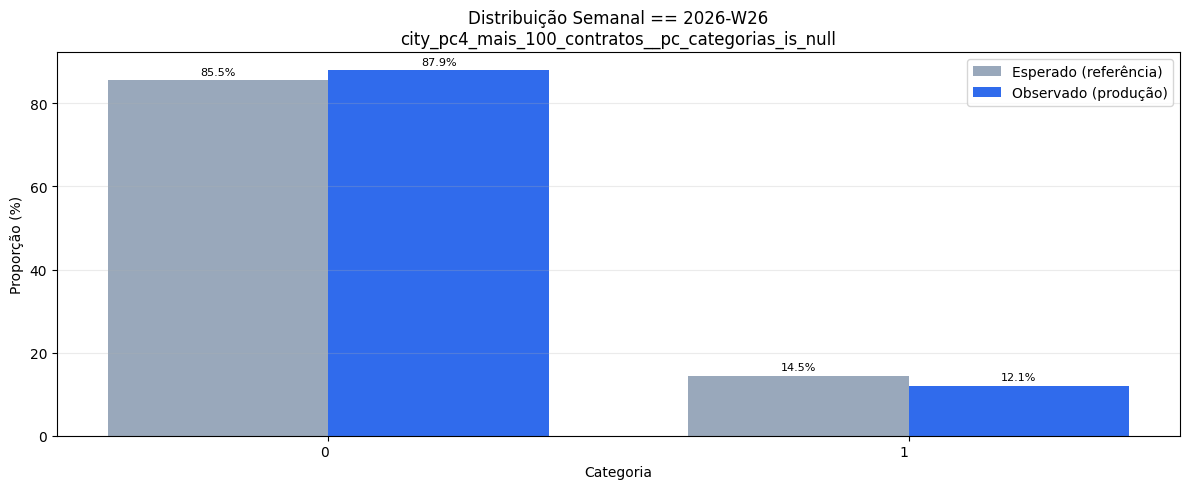

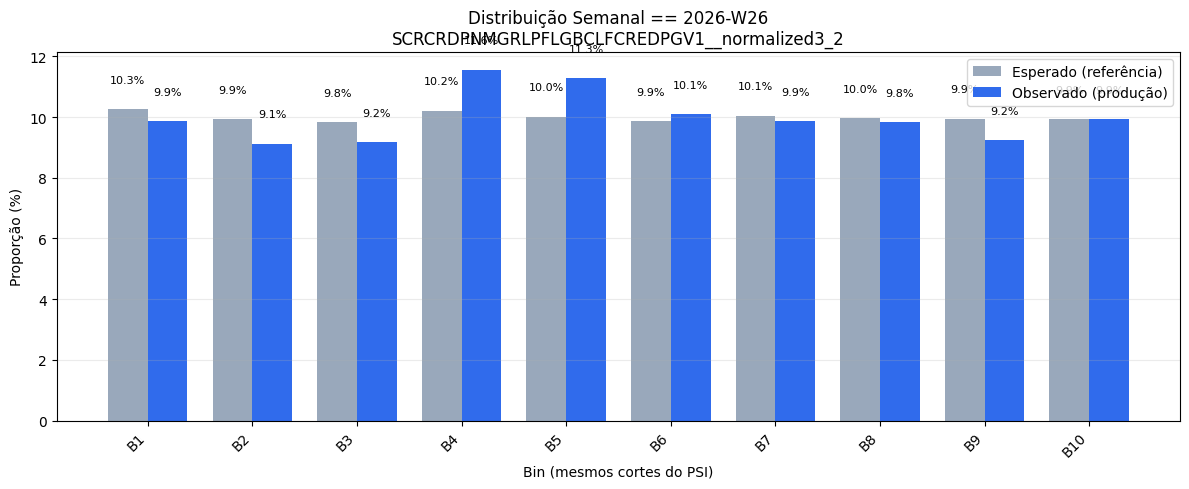

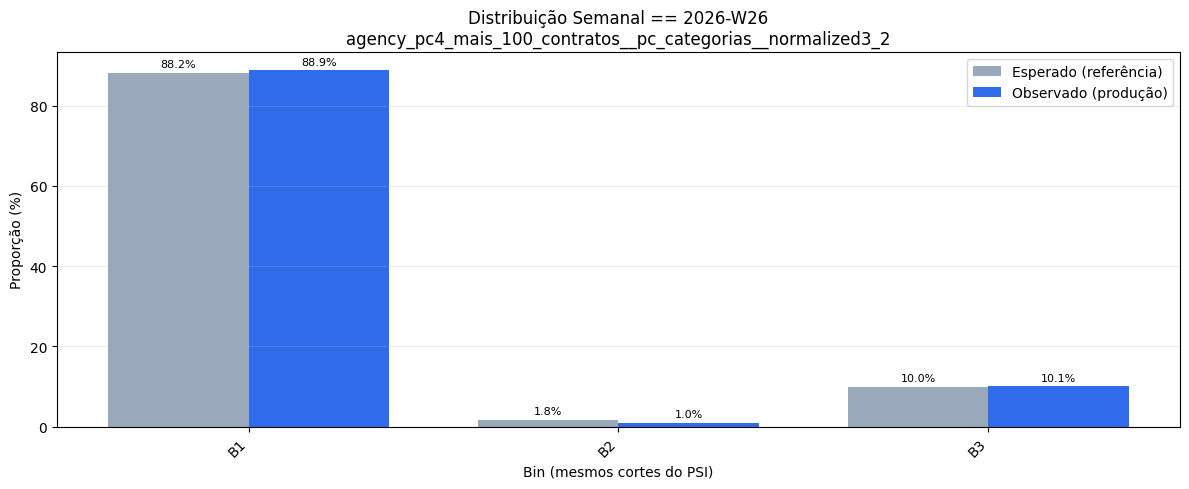

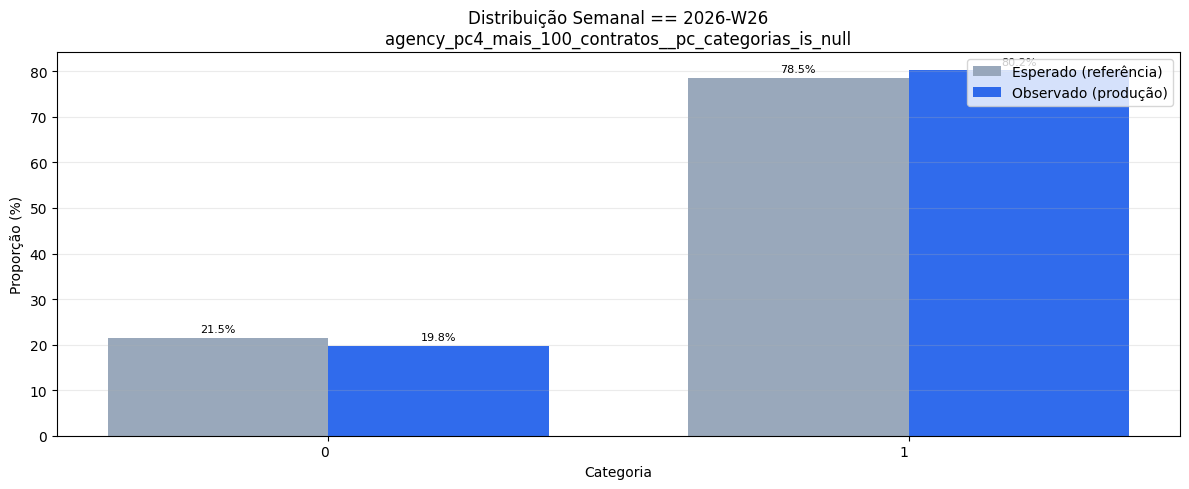

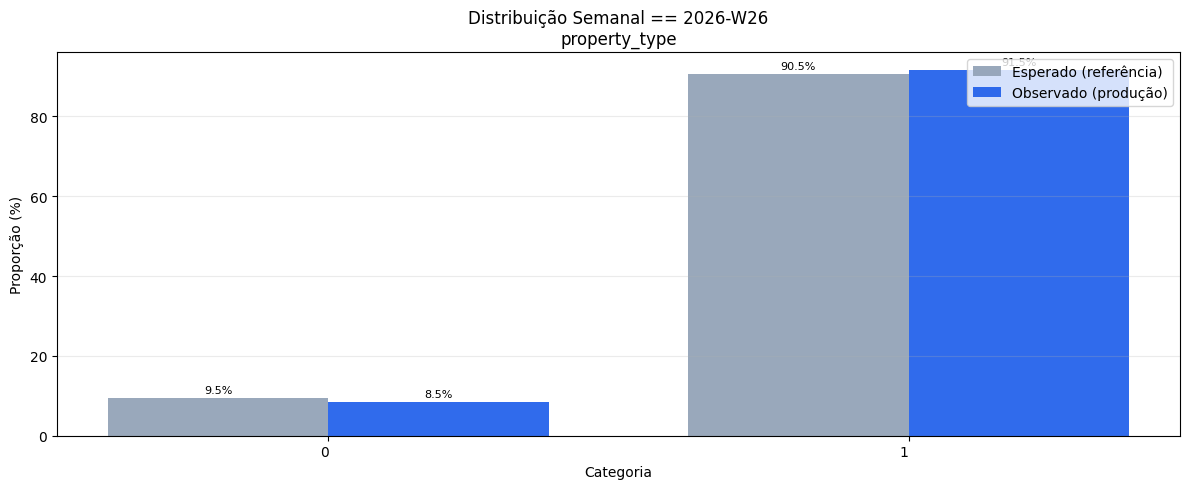

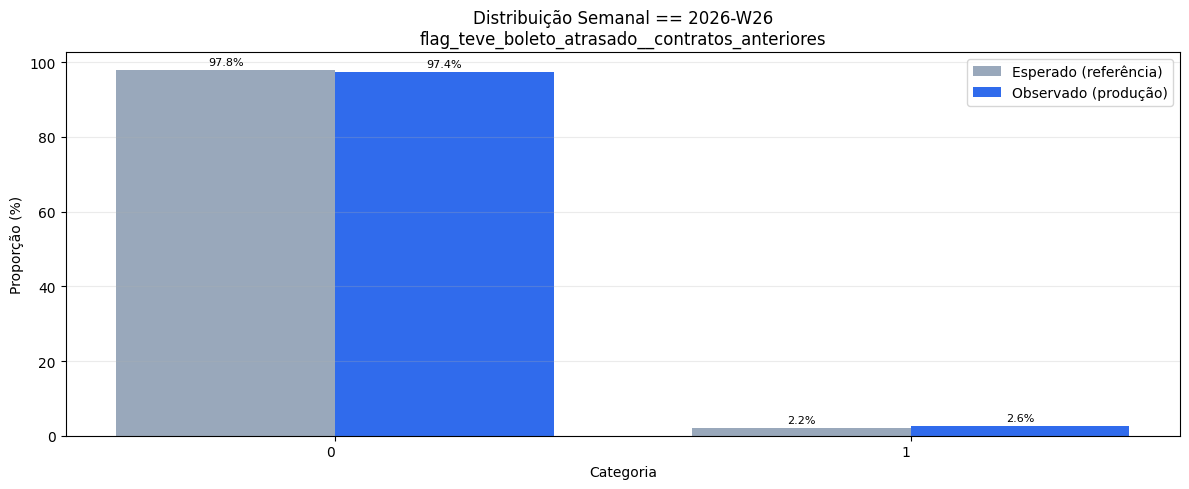

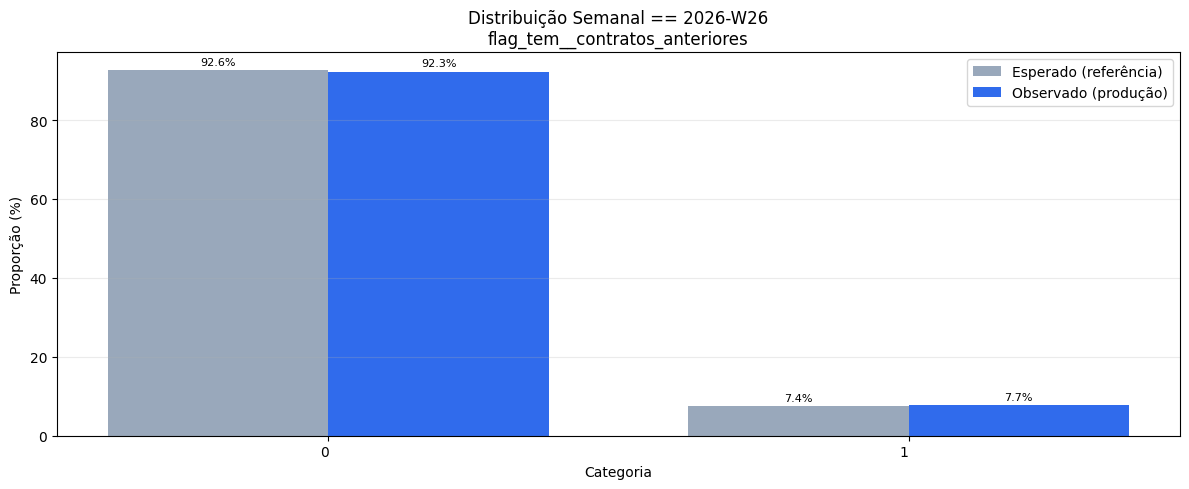

In [49]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_week,
    artifact=psi_reference_artifact,
    variables=model_vars,
    top_n=12,
    title_prefix=f"Distribuição Semanal == {target_week}",
)

# Apagar

Garantir que não estamos comprando SERASA para esse público

10-11% do público OOT passa direto por BVS (Blend4).
15-17% é Rating E pelo Score BVS.

In [50]:
REGRA_ORDER = ["BLEND4", "E_BVS"]
REGRA_COLOR_MAP = {
    "BLEND4": "#3B82F6",
    "E_BVS": "#F59E0B",
}

df_monitor = filter_monitoring_week_window(df_uniprop, n_weeks=6, mode="rolling")

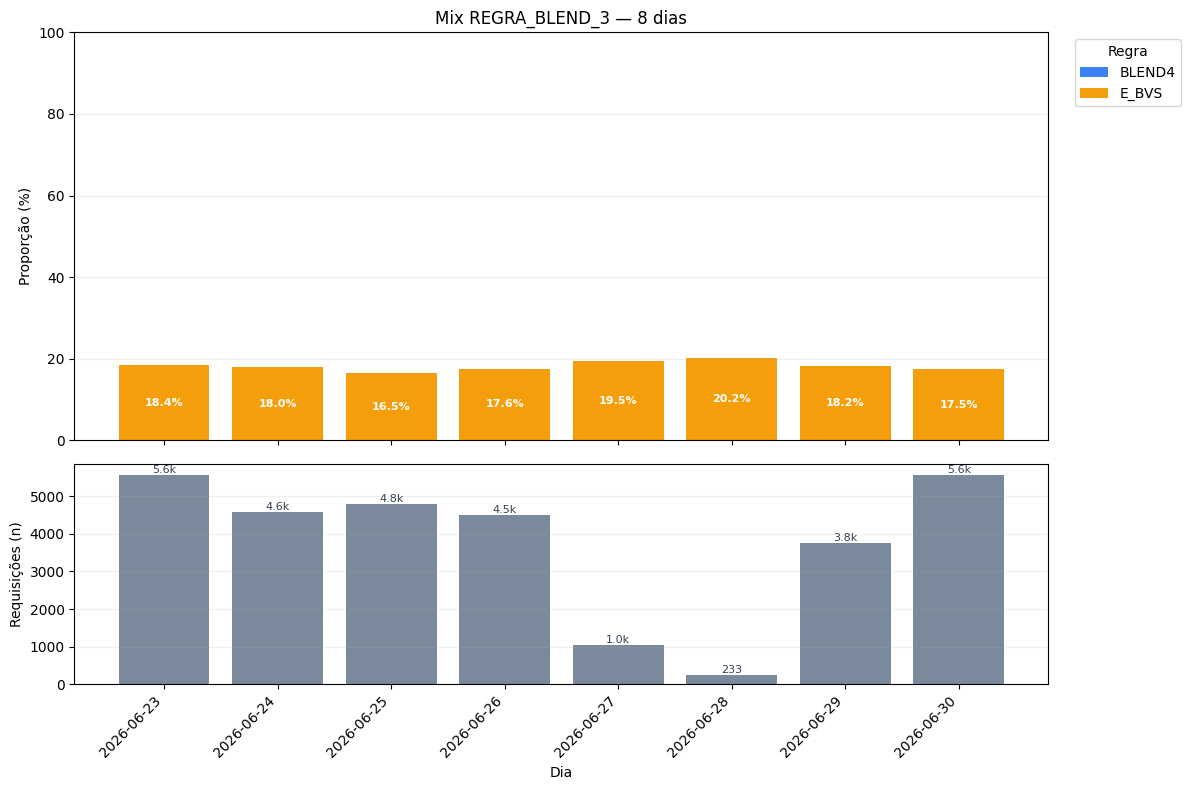

In [51]:
# Diário (mesma base, janela diária)
df_daily = filter_monitoring_window(df_monitor, n_days=8, mode="rolling")
plot_daily_mix(
    df_daily,
    category_col="REGRA_BLEND_3",
    title=f"Mix REGRA_BLEND_3 — 8 dias",
    category_order=REGRA_ORDER,
    color_map=REGRA_COLOR_MAP,
    legend_title="Regra",
    min_label_pct=3.0,
)

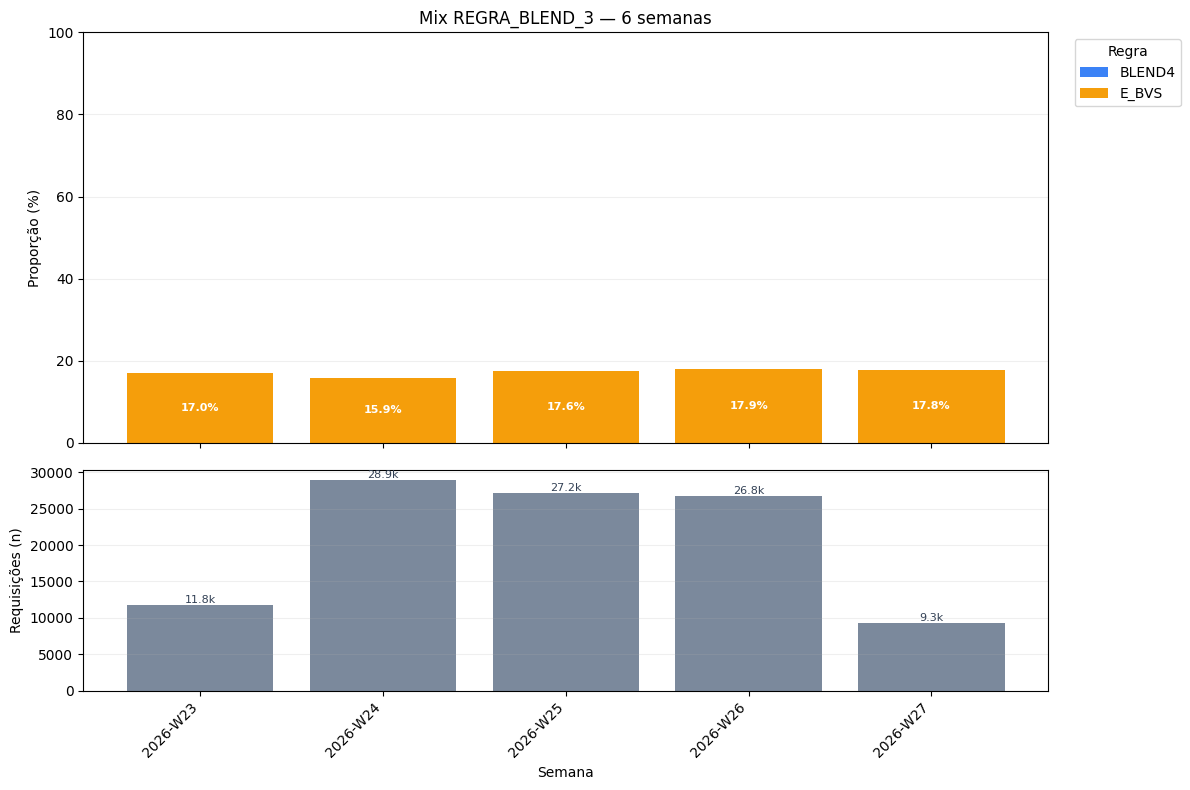

In [52]:
# Semanal
plot_weekly_mix(
    df_monitor,
    category_col="REGRA_BLEND_3",
    title="Mix REGRA_BLEND_3 — 6 semanas",
    category_order=REGRA_ORDER,
    color_map=REGRA_COLOR_MAP,
    legend_title="Regra",
    min_label_pct=3.0,
)

In [ ]:
df_bvs_mon = df_monitor[df_monitor["REGRA_BLEND_4"] == "E_BVS"].copy()

df_bvs_mon["status_serasa"] = np.where(
    df_bvs_mon["SCORE_SERASA"].isna(),  #Estou considerando que o score serasa é nulo quando não tem SERASA (Valores especiais?)
    "Conforme (sem SERASA)",
    "Violação (com SERASA)",
)

SERASA_STATUS_ORDER = ["Conforme (sem SERASA)", "Violação (com SERASA)"]
SERASA_STATUS_COLORS = {
    "Conforme (sem SERASA)": "#22C55E",
    "Violação (com SERASA)": "#EF4444",
}

In [ ]:
plot_weekly_mix(
    df_bvs_mon,
    category_col="status_serasa",
    title="E_BVS — conformidade SCORE_SERASA (semanal)",
    category_order=SERASA_STATUS_ORDER,
    color_map=SERASA_STATUS_COLORS,
    legend_title="Status SERASA",
    reverse_stack=True,  # violação no topo, mais visível
    min_label_pct=1.0,
)

In [ ]:
df_E_BVS_mon = df_monitor[df_monitor["REGRA_BLEND_3"] == "E_BVS"].copy()

score_bvs = pd.to_numeric(df_E_BVS_mon["SCORE_BVS"], errors="coerce")

df_E_BVS_mon["status_bvs"] = np.select(
    [
        score_bvs.isna(),
        (score_bvs >= 0) & (score_bvs <= 334),
        (score_bvs < 0) | (score_bvs > 334),
    ],
    [
        "Violação (NaN)",
        "Conforme (0-334)",
        "Violação (fora da faixa)",
    ],
    default="Violação (NaN)",
)

BLEND4_STATUS_ORDER = [
    "Conforme (0-334)",
    "Violação (NaN)",
    "Violação (fora da faixa)",
]
BLEND4_STATUS_COLORS = {
    "Conforme (0-334)": "#22C55E",
    "Violação (NaN)": "#EF4444",
    "Violação (fora da faixa)": "#F97316",
}

In [ ]:
plot_weekly_mix(
    df_E_BVS_mon,
    category_col="status_bvs",
    title="E_BVS — conformidade SCORE_BVS (semanal)",
    category_order=BLEND4_STATUS_ORDER,
    color_map=BLEND4_STATUS_COLORS,
    legend_title="Status BVS",
    reverse_stack=True,
    min_label_pct=1.0,
)

In [ ]:
df_blend4_mon = df_monitor[df_monitor["REGRA_BLEND_4"] == "BLEND4"].copy()

# Opcional: alinhar com filtros do notebook
# df_blend4_mon = df_blend4_mon[
#     (df_blend4_mon["income"] > 0) & (df_blend4_mon["qtd_proponentes"] == 1)
# ]

score_serasa = pd.to_numeric(df_blend4_mon["SCORE_SERASA"], errors="coerce")
score_bvs = pd.to_numeric(df_blend4_mon["SCORE_BVS"], errors="coerce")

df_blend4_mon["status_serasa"] = np.select(
    [
        score_serasa.isna(),
        (score_serasa >= 0) & (score_serasa <= 1000),
        (score_serasa < 0) | (score_serasa > 1000),
    ],
    [
        "Violação (NaN)",
        "Conforme (0–1000)",
        "Violação (fora da faixa)",
    ],
    default="Violação (NaN)",
)

df_blend4_mon["status_bvs"] = np.select(
    [
        score_bvs.isna(),
        (score_bvs >= 0) & (score_bvs <= 1000),
        (score_bvs < 0) | (score_bvs > 1000),
    ],
    [
        "Violação (NaN)",
        "Conforme (0–1000)",
        "Violação (fora da faixa)",
    ],
    default="Violação (NaN)",
)

BLEND4_STATUS_ORDER = [
    "Conforme (0–1000)",
    "Violação (NaN)",
    "Violação (fora da faixa)",
]
BLEND4_STATUS_COLORS = {
    "Conforme (0–1000)": "#22C55E",
    "Violação (NaN)": "#EF4444",
    "Violação (fora da faixa)": "#F97316",
}

In [ ]:
plot_weekly_mix(
    df_blend4_mon,
    category_col="status_serasa",
    title="BLEND4 — conformidade SCORE_SERASA (semanal)",
    category_order=BLEND4_STATUS_ORDER,
    color_map=BLEND4_STATUS_COLORS,
    legend_title="Status SERASA",
    reverse_stack=True,
    min_label_pct=1.0,
)

In [ ]:
plot_weekly_mix(
    df_blend4_mon,
    category_col="status_bvs",
    title="BLEND4 — conformidade Score BVS (semanal)",
    category_order=BLEND4_STATUS_ORDER,
    color_map=BLEND4_STATUS_COLORS,
    legend_title="Status BVS",
    reverse_stack=True,
    min_label_pct=1.0,
)

## Dia e Semana Raw

In [ ]:
WINDOW_DAYS = 8

df_daily = filter_monitoring_window(
    df_uniprop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)
print(f"Período: {df_daily['requested_at'].min()} → {df_daily['requested_at'].max()}")
print(f"Volume total: {len(df_daily):,}")

In [ ]:
WINDOW_WEEKS = 6

df_weekly = filter_monitoring_week_window(
    df_uniprop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)
print(f"Semanas: {df_weekly['year_week'].nunique()} | Volume: {len(df_weekly):,}")
print(f"Período: {df_weekly['requested_at'].min()} → {df_weekly['requested_at'].max()}")

In [ ]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_bvs_score_psi_reference.pkl"
psi_reference_artifact_bvs = load_psi_reference(PSI_REFERENCE_PATH)

In [ ]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "psi_income_rental_reference.pkl"
psi_reference_artifact_raw = load_psi_reference(PSI_REFERENCE_PATH)

In [ ]:
daily_blend4 = df_daily[df_daily["message_decisao"] == "BLEND_4"].copy()
weekly_blend4 = df_weekly[df_weekly["message_decisao"] == "BLEND_4"].copy()

psi_daily_bvs = monitor_daily_psi(
    df_production=daily_blend4,
    artifact=psi_reference_artifact_bvs,
    date_col="requested_at",
    baseline_ref=psi_baseline_ref,
    variables=["SCORE_BVS"],
)

psi_weekly_bvs = monitor_weekly_psi(
    df_production=weekly_blend4,
    artifact=psi_reference_artifact_bvs,
    baseline_ref=psi_baseline_ref,
    variables=["SCORE_BVS"],
)

psi_daily_income_rental = monitor_daily_psi(
    df_production=daily_blend4,
    artifact=psi_reference_artifact_raw,
    date_col="requested_at",
    baseline_ref=psi_baseline_ref,
    variables=["income", "rental_value"],
)

psi_weekly_income_rental = monitor_weekly_psi(
    df_production=weekly_blend4,
    artifact=psi_reference_artifact_raw,
    baseline_ref=psi_baseline_ref,
    variables=["income", "rental_value"],
)

In [ ]:
target_day = pd.to_datetime(daily_blend4["requested_at"]).max().strftime("%Y-%m-%d")
print(f"Target day: {target_day}")
df_day = daily_blend4[
    pd.to_datetime(daily_blend4["requested_at"]).dt.strftime("%Y-%m-%d") == target_day
]

In [ ]:
target_week = target_week = week_order[-2]
print(f"Target Week == {target_week} (Última Semana Completa)")
df_week = weekly_blend4[
    weekly_blend4["year_week"] == target_week]

In [ ]:
# psi_daily
# POR QUE TEM NAN

## PSI RAW BVS

In [ ]:
pivot = (
    psi_daily_bvs
    .pivot(index="variable", columns="monitoring_day", values="psi")
    .reindex(["SCORE_BVS"])
    .rename(index={"SCORE_BVS": "Score BVS"})
)
fig, ax = plt.subplots(figsize=(10, 2))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI diário por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Dia")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

In [ ]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_day,
    artifact=psi_reference_artifact_bvs,
    variables=["SCORE_BVS"],
    title_prefix=f"Distribuição diária — {target_day}",
)

In [ ]:
pivot = (
    psi_weekly_bvs
    .pivot(index="variable", columns="monitoring_week", values="psi")
    .reindex(["SCORE_BVS"])
    .rename(index={"SCORE_BVS": "Score BVS"})
)
fig, ax = plt.subplots(figsize=(10, 2))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI Semanal por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Semanas")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

In [ ]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_week,
    artifact=psi_reference_artifact_bvs,
    variables=["SCORE_BVS"],
    title_prefix=f"Distribuição Semanal == {target_week}",
)

## PSI RAW Renda e Aluguel

In [ ]:
pivot = (
    psi_daily_income_rental
    .pivot(index="variable", columns="monitoring_day", values="psi")
    .reindex(["income", "rental_value"])
    .rename(index={"income": "Renda", "rental_value": "Aluguel"})
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI diário por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Dia")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

In [ ]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_day,
    artifact=psi_reference_artifact_raw,
    variables=["income", "rental_value"],
    title_prefix=f"Distribuição diária — {target_day}",
)

In [ ]:
pivot = (
    psi_weekly_income_rental
    .pivot(index="variable", columns="monitoring_week", values="psi")
    .reindex(["income", "rental_value"])
    .rename(index={"income": "Renda", "rental_value": "Aluguel"})
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI Semanal por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Semanas")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

In [ ]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_week,
    artifact=psi_reference_artifact_raw,
    variables=["income", "rental_value"],
    title_prefix=f"Distribuição Semanal == {target_week}",
)